**READ Data set of Laue pattern image H5 files**

with or without stacked images, saved in several or a single dataset 

# IMPORTS

In [ ]:
%matplotlib widget

import os, time, copy
import itertools
import glob

import h5py
import multiprocessing
import numpy as np
from pathlib import Path
from tqdm import tqdm


import matplotlib.pyplot as plt
import matplotlib
from ipywidgets import interact, IntSlider, Button, HBox, VBox, Output, FloatRangeSlider

TODO: 

- see other grid daxm without drift (?) and data structure different

- auto detection if stacked images or not and datastructure exploration (glob) (then define some vairables)

- use magnifix to load data (rather than fr-crg), faster?


# some functions

In [ ]:
def get_dataset_info(h5file, dataset_path):
    """ return: array shape (nb of images, pixelY dim, pixelX dim),
                dtype,
                total size in Mbytes of a dataset in h5file"""
    with h5py.File(h5file, 'r', locking=False) as f:
        dataset = f[dataset_path]
        shape = dataset.shape
        dtype = dataset.dtype
        size_bytes = dataset.nbytes  # Total size in bytes
        size_Mbytes = size_bytes/(1024)**2
        return shape, dtype, size_Mbytes

# peaksearch (integer posistion of hot blob) for part of image

import LaueTools.readmccd as rmccd
import LaueTools.imageprocessing as ImProc
import LaueTools.dict_LaueTools as DictLT
import LaueTools.generaltools as GT

def peaksearch(
    dataimage,
    CCDLabel='EIGER_4MCdTe',
    IntensityThreshold=4000,
    boxlimits_xy=[0, 2068, 0, 2162],
    filter_by_roi=True
):
    """
    Detect peaks in a 2D image and optionally filter them by a region of interest (ROI).

    Parameters:
    -----------
    dataimage : numpy.ndarray
        Input 2D image data.
    CCDLabel : str, optional
        Label for the CCD detector (default: 'EIGER_CdTe').
    IntensityThreshold : int, optional
        Threshold for peak detection (default: 4000).
    boxlimits_xy : list, optional
        Region of interest (ROI) as [xmin, xmax, ymin, ymax] (default: [0, 2068, 0, 2162]).
    filter_by_roi : bool, optional
        If True, filter peaks to only include those within the ROI (default: True).

    Returns:
    --------
    res_filtered : list of tuples
        List of (x, y, intensity) tuples for peaks within the ROI.
    """
    # Compute background and filtered image
    backgroundimage = ImProc.compute_autobackground_image(dataimage, boxsizefilter=10)
    Data2 = ImProc.computefilteredimage(
        dataimage,
        backgroundimage,
        CCDLabel,
        usemask=True,
        formulaexpression='A-1.02*B')
    
    # Detect local maxima (peaks)
    res = ImProc.LocalMaxima_from_thresholdarray(
        Data2,
        IntensityThreshold=IntensityThreshold,
        rois=None,
        framedim= DictLT.dict_CCD[CCDLabel],
        outputIpixmax=False)
    
    # Filter peaks by ROI if enabled
    if filter_by_roi:
        xmin, xmax, ymin, ymax = boxlimits_xy
        res_filtered = [
            (int(x), int(y))
            for (x, y) in res
            if xmin <= x <= xmax and ymin <= y <= ymax]
        return res_filtered
    else:
        return res


def extract_pixels_for_scan_multipleimages(args):
    """
    suited to Extract 100 pixels from 100-150 images in several daxm scans.

    Args:
        args: Tuple of (h5file, scan_index, pixel_coords, image_indices)
              - h5file: Path to HDF5 file.
              - scan_index: Index of the scan (1 to 1156).
              - pixel_coords: List of (x, y) tuples (100 pixels).
              - image_indices: List of image indices to extract (100-150).

    Returns:
        numpy.ndarray: Array of shape (n_images, 100) with pixel values.
    """
    h5file, scan_index, pixel_coords, image_indices = args
    with h5py.File(h5file, 'r', locking=False) as f:
        scan_path = f'{int(scan_index)}.1/measurement/eiger4m'
        # Load only the selected images for this scan
        scan_data = f[scan_path][image_indices]  # Shape: (n_images, height, width)

        # Extract pixels for all selected images
        n_images = len(image_indices)
        result = np.zeros((n_images, len(pixel_coords)))
        for img_idx, i in enumerate(image_indices):
            for pixel_idx, (x, y) in enumerate(pixel_coords):
                result[img_idx, pixel_idx] = scan_data[img_idx, y, x]  # Note: (image, y, x)
        return result


# [TEST] read 1 daxm scan image

In [ ]:
# one dataset contains 34*34 h5 files (daxm scan), each daxm scan H5 file has got 501 stacked images

h5file = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
h5file+='CrZr/CrZr_fast_daxm_grid_1fileperscan/CrZr_fast_daxm_grid_1fileperscan.h5'

row, col =17, 17
grid_daxm_dimensions = 34,34
ix = row*grid_daxm_dimensions[0]+col

scanindex=ix+1

imageindex =0 # from 0 to 500 included
dataset_path = f'{scanindex}.1/measurement/eiger4m'
with h5py.File(h5file, 'r', locking=False) as f:
    lp = f[dataset_path][imageindex]
    #lp = f[dataset_path][0:30]

In [ ]:
# 34*34 h5 files, ecah file has got 501 stacked images
h5file = '/data/visitor/a321217/bm32/20260707/RAW_DATA/CRZR/CRZR_grid_index_0_row_col_0_0/CRZR_grid_index_0_row_col_0_0.h5'

with h5py.File(h5file, 'r', locking=False) as f:
    scanindex=1
    #scandata = f[f'{scanindex}.1/measurement/eiger4m'][()]   # whole scan
    scandata = f[f'{scanindex}.1/measurement/eiger4m'][0]  
    (nbimages_per_scan, Ydim, Xdim),_,_=get_dataset_info(h5file, f'{scanindex}.1/measurement/eiger4m')
    print('nbimages_per_scan, Ydim, Xdim:',nbimages_per_scan, Ydim, Xdim)

# USER DATA EXPERIMENTAL SCAN PARAMETERS

In [ ]:
# ---grid daxm  Parameters ---
if 0:
    # a single h5 file cointains several daxm scans with a scan#### subfolder each.
    # then each scan#### contains a single h5 file of stacked images
    h5file = '/data/visitor/a321217/bm32/20260707/RAW_DATA/CrZr/CrZr_fast_daxm_grid_1fileperscan/CrZr_fast_daxm_grid_1fileperscan.h5'
    samplename = 'CrZr'
    SINGLE_BLISS_DATASET = True
    DAXMSCAN_STACKED_IMAGES = True
    grid_daxm_dimensions = (34, 34)  # slow  // yech , fast  // xech


if 0:# 34*34 h5 files, ecah file has got 501 stacked images
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    h5file_template += 'CRZR/CRZR_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/CRZR_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = True
    grid_daxm_dimensions = (34, 34)  # slow  // yech , fast  // xech


if 0:
    # 34*34 h5 files, ecah file has got 501 stacked images   1 sec exposure
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    h5file_template += 'Zr4/Zr4_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/Zr4_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    samplename = 'Zr4'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = True
    # up to row 5 and col 9  , commplete up to 4 22   nrows=nslow 5    ncols=nfast=23
    grid_daxm_dimensions = (5, 23)  # slow  // yech , fast  // xech


if 0:     
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    h5file_template += 'Zrsamedi/Zrsamedi_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/Zrsamedi_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    samplename = 'Zrsamedi'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = False  # 501 independent images in scan0001
    # up to row 5 and col 9  , commplete up to 4 22   nrows=nslow 5    ncols=nfast=23
    grid_daxm_dimensions = (1, 6)  # slow  // yech , fast  // xech


if 0:  
    # exposure  0.1 sec
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    samplename = '3Dmap_grain1'
    h5file_template += '{samplename}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = False  # 501 independent images in scan0001
    grid_daxm_dimensions = (17, 13)  # slow  // yech , fast  // xech


if 0:  
    # exposure  0.1 sec
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    samplename = '3Dmap_grain2'
    h5file_template += '{samplename}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = False  # 501 independent images in scan0001
    grid_daxm_dimensions = (11, 7)  # slow  // yech , fast  // xech


if 0:  
    # exposure  0.1 sec
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    samplename = '3Dmap_grain3'
    h5file_template += '{samplename}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = False  # 501 independent images in scan0001
    grid_daxm_dimensions = (21, 25)  # row slow  // yech , col fast  // xech

if 0:  # TO CHECK
    # exposure  0.3 sec
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    samplename = 'Zr5_griddaxm'
    h5file_template += '{samplename}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = False  # 401 independent images in scan0001
    grid_daxm_dimensions = (14, 28)  # row slow  // yech , col fast  // xech

if 0:  # TO CHECK
    # exposure  1.0 sec
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    samplename = 'Zr5_griddaxm_1sec'
    h5file_template += '{samplename}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = False  # 401 independent images in scan0001
    grid_daxm_dimensions = (3, 12)  # row slow  // yech , col fast  // xech

if 0:  # TO CHECK
    # exposure  2 sec
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    samplename = 'Zr5_griddaxm_2sec'
    h5file_template += '{samplename}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = False  # 401 independent images in scan0001
    grid_daxm_dimensions = (1, 9)  # row slow  // yech , col fast  // xech

if 1:  # TO CHECK
    # exposure  0.05 sec
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    samplename = 'Zr5_griddaxm_0p05sec'
    h5file_template += '{samplename}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = False  # 401 independent images in scan0001
    grid_daxm_dimensions = (10, 10)  # row slow  // yech , col fast  // xech

if 0:  # TO CHECK
    # exposure  0.45 sec
    h5file_template = '/data/visitor/a321217/bm32/20260707/RAW_DATA/'
    samplename = 'Zr6_griddaxm_0p45sec'
    h5file_template += '{samplename}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}/{samplename}_grid_index_{scanindex}_row_col_{rowindex}_{colindex}.h5'
    SINGLE_BLISS_DATASET = False
    DAXMSCAN_STACKED_IMAGES = False  # 401 independent images in scan0001
    grid_daxm_dimensions = (11, 21)  # row slow  // yech , col fast  // xech

# GUIs browser of laue pattern images over a grid of daxm scans

this 2D space map of daxm scans is a 5D data sets
(nbcols_xech, nbrows_yech, nbimages_per_scan_daxm, detectordim1, detectordim2)

allows to:

- get a set of pixels on detector to fill the variable `clicked_coords` and later plot corresponding mosaic plots or grain imaging
- get `bbox` to perform peaksearch in it

##  GUI to zoom and apply peaksearch selected region

create `pixel_coords`  from peak search

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Button, HBox, Output, IntSlider, interact
import h5py
from matplotlib.gridspec import GridSpec

# ----------------
# --- Plot setup ---
fig = plt.figure(figsize=(12, 5))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.1)
ax = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[1], sharey=ax)
plt.subplots_adjust(bottom=0.2)

col0 = grid_daxm_dimensions[1]//2
row0 = grid_daxm_dimensions[0]//2

ix0 = row0 * grid_daxm_dimensions[1] + col0

imageindex0 = 0

if SINGLE_BLISS_DATASET:
    scanindex0 = ix0 + 1
    with h5py.File(h5file, 'r', locking=False) as f:
        lp = f[f'{scanindex0}.1/measurement/eiger4m'][imageindex0]
        (nbimages_per_scan, Ydim, Xdim), _, _ = get_dataset_info(h5file, f'{scanindex0}.1/measurement/eiger4m')
        print('nbimages_per_scan, Ydim, Xdim:', nbimages_per_scan, Ydim, Xdim)
else:
    scanindex0 = ix0
    h5file = h5file_template.format(scanindex=scanindex0, rowindex=row0, colindex=col0, samplename=samplename)
    print('h5file', h5file)
    with h5py.File(h5file, 'r', locking=False) as f:
        lp = f[f'1.1/measurement/eiger4m'][imageindex0]
        (nbimages_per_scan, Ydim, Xdim), _, _ = get_dataset_info(h5file, f'1.1/measurement/eiger4m')
        print('nbimages_per_scan, Ydim, Xdim:', nbimages_per_scan, Ydim, Xdim)

print('first image shape', lp.shape)
im = ax.imshow(lp, extent=[0, lp.shape[1], lp.shape[0], 0])
ax.set_title(f'Scan #{scanindex0}: row, col = ({row0}, {col0}), Image: {imageindex0}')
ax.set_xlabel('X')
ax.set_ylabel('Y')

# Plot for integrated intensity
ax_right.set_title("Integrated Intensity")
ax_right.set_xlabel("Intensity")
ax_right.set_ylabel('Y')
ax_right.grid(True)

# Store clicked coordinates and current scan/image indices
clicked_coords = []
current_scanindex = None
current_imageindex = None
select_mode = False  # Toggle for selection mode
bbox = [0, Xdim, 0, Ydim]  # Initialize bbox with full image dimensions: [xmin, xmax, ymin, ymax]
horizontal_lines_y = []  # Store Y-positions of horizontal lines
draw_mode_active = False  # Flag to indicate if draw mode is active

# --- UI Elements ---
select_button = Button(description="Toggle Select Mode", button_style='')
save_button = Button(description="Save Selected Pixels", button_style='')
draw_line_button = Button(description="Draw Horizontal Line", button_style='')
clear_lines_button = Button(description="Clear All Lines", button_style='')
output = Output()  # For printing messages

# --- Click event handler ---
def on_click(event):
    global select_mode, draw_mode_active, horizontal_lines_y
    if select_mode and event.inaxes == ax:
        x, y = float(event.xdata), float(event.ydata)
        clicked_coords.append((int(x), int(y)))
        with output:
            output.clear_output()
            print(f"Clicked at: (scan={current_scanindex}, image={current_imageindex}, x={x:.1f}, y={y:.1f})")

    if draw_mode_active and event.inaxes == ax:
        y = float(event.ydata)
        horizontal_lines_y.append(y)
        ax_right.axhline(y=y, color='red', linestyle='--', linewidth=1)
        draw_mode_active = False
        draw_line_button.description = "Draw Horizontal Line"
        fig.canvas.draw_idle()

fig.canvas.mpl_connect('button_press_event', on_click)

# --- Button event handlers ---
def on_select_button_click(b):
    global select_mode
    select_mode = not select_mode
    with output:
        output.clear_output()
        print(f"Select mode: {'ON' if select_mode else 'OFF'}")
        print(f"Current bbox: {bbox}")

def on_save_button_click(b):
    if clicked_coords:
        np.save('clicked_pixels.npy', np.array(clicked_coords))
        with output:
            output.clear_output()
            print(f"Saved {len(clicked_coords)} coordinates to 'clicked_pixels.npy'")
    else:
        with output:
            output.clear_output()
            print("No coordinates to save!")

def on_draw_line_button_click(b):
    global draw_mode_active
    draw_mode_active = True
    b.description = "Click on the left plot to draw line"

def on_clear_lines_button_click(b):
    global horizontal_lines_y
    horizontal_lines_y = []
    for line in ax_right.lines[:]:
        if line.get_color() == 'red' and line.get_linestyle() == '--':
            line.remove()
    fig.canvas.draw_idle()

select_button.on_click(on_select_button_click)
save_button.on_click(on_save_button_click)
draw_line_button.on_click(on_draw_line_button_click)
clear_lines_button.on_click(on_clear_lines_button_click)

# --- Update stored limits on user interaction ---
def on_draw(event):
    global current_xlim, current_ylim, bbox
    current_xlim = ax.get_xlim()
    current_ylim = ax.get_ylim()

    xmin = int(min(current_xlim[0], current_xlim[1])) + 1
    xmax = int(max(current_xlim[0], current_xlim[1])) - 1
    ymin = int(min(current_ylim[0], current_ylim[1])) + 1
    ymax = int(max(current_ylim[0], current_ylim[1])) - 1

    bbox = [xmin, xmax, ymin, ymax]

fig.canvas.mpl_connect('draw_event', on_draw)

# --- Update integrated intensity plot ---
def update_integrated_intensity(img):
    ax_right.clear()
    integrated_intensity = np.sum(img, axis=1)  # Sum along columns (Y-axis)
    ax_right.plot(integrated_intensity, np.arange(len(integrated_intensity)), 'k-')
    ax_right.set_title("Integrated Intensity")
    ax_right.set_xlabel("Intensity")
    ax_right.set_ylabel('Y')
    ax_right.grid(True)

    # Redraw horizontal lines
    for y in horizontal_lines_y:
        ax_right.axhline(y=y, color='red', linestyle='--', linewidth=1)

    fig.canvas.draw_idle()

# --- Show image function ---
def show_image(vmin=0, vmax=200, imageindex=0, colindex=col0, rowindex=row0):
    global current_scanindex, current_imageindex, img, bbox

    current_xlim0 = ax.get_xlim()
    current_ylim0 = ax.get_ylim()

    ax.clear()

    if SINGLE_BLISS_DATASET:
        with h5py.File(h5file, 'r', locking=False) as f:
            ix = rowindex * grid_daxm_dimensions[1] + colindex
            scanindex = ix + 1
            img = f[f'{scanindex}.1/measurement/eiger4m'][imageindex]
    else:
        ix = rowindex * grid_daxm_dimensions[1] + colindex
        scanindex = ix
        h5file = h5file_template.format(scanindex=scanindex, rowindex=rowindex, colindex=colindex, samplename=samplename)
        # print('h5file', h5file)
        # print('imageindex', imageindex)
        with h5py.File(h5file, 'r', locking=False) as f:
            img = f[f'1.1/measurement/eiger4m'][imageindex]

    im = ax.imshow(img, vmin=vmin, vmax=vmax, extent=[0, img.shape[1], img.shape[0], 0])
    ax.set_title(f'Scan #{scanindex}: row, col = ({rowindex}, {colindex}), Image: {imageindex}')

    # Restore zoom/pan
    ax.set_xlim(current_xlim0)
    ax.set_ylim(current_ylim0)

    # Update bbox with current axis limits
    bbox = [current_xlim0[0], current_xlim0[1], current_ylim0[0], current_ylim0[1]]

    # Update integrated intensity plot
    update_integrated_intensity(img)

    fig.canvas.draw_idle()

    # Update current scan and image indices
    current_scanindex = scanindex
    current_imageindex = imageindex

# --- Create sliders ---
interact(
    show_image,
    vmin=0,
    vmax=IntSlider(min=20, max=9000, step=5, value=200, continuous_update=False),
    imageindex=IntSlider(min=0, max=nbimages_per_scan-1, step=1, value=0, continuous_update=False, tooltip='image index in the daxm scan'),
    colindex=IntSlider(min=0, max=grid_daxm_dimensions[1]-1, step=1, value=col0, continuous_update=False, tooltip='along Xech'),
    rowindex=IntSlider(min=0, max=grid_daxm_dimensions[0]-1, step=1, value=row0, continuous_update=False, tooltip='along Yech')
)

# Display the buttons
display(HBox([select_button, save_button, draw_line_button, clear_lines_button]), output)

plt.show()

In [ ]:
'current `bbox`',bbox, 'current `clicked_coords`',clicked_coords, 'current `img`', img

In [ ]:
pixel_coords = peaksearch(img, IntensityThreshold=200,boxlimits_xy=bbox)
print(f'found {len(pixel_coords)} peaks from peaksearch and stored in `pixel_coords`')

## [OPTION] GUI allowing to extract and compare intensity profiles

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import Button, HBox, Output, IntSlider, interact
import h5py
from matplotlib.gridspec import GridSpec

# ----------------
# --- Plot setup ---
fig = plt.figure(figsize=(12, 5))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.1)
ax = fig.add_subplot(gs[0])
ax_right = fig.add_subplot(gs[1], sharey=ax)
plt.subplots_adjust(bottom=0.2)

ix0 = row0 * grid_daxm_dimensions[1] + col0

if SINGLE_BLISS_DATASET:
    scanindex0 = ix0 + 1
    with h5py.File(h5file, 'r', locking=False) as f:
        lp = f[f'{scanindex0}.1/measurement/eiger4m'][imageindex0]
        (nbimages_per_scan, Ydim, Xdim), _, _ = get_dataset_info(h5file, f'{scanindex0}.1/measurement/eiger4m')
        print('nbimages_per_scan, Ydim, Xdim:', nbimages_per_scan, Ydim, Xdim)
else:
    scanindex0 = ix0
    h5file = h5file_template.format(scanindex=scanindex0, rowindex=row0, colindex=col0, samplename=samplename)
    print('h5file', h5file)
    with h5py.File(h5file, 'r', locking=False) as f:
        lp = f[f'1.1/measurement/eiger4m'][imageindex0]
        (nbimages_per_scan, Ydim, Xdim), _, _ = get_dataset_info(h5file, f'1.1/measurement/eiger4m')
        print('nbimages_per_scan, Ydim, Xdim:', nbimages_per_scan, Ydim, Xdim)

print('first image shape', lp.shape)
im = ax.imshow(lp, extent=[0, lp.shape[1], lp.shape[0], 0])
ax.set_title(f'Scan #{scanindex0}: row, col = ({row0}, {col0}), Image: {imageindex0}')
ax.set_xlabel('X')
ax.set_ylabel('Y')

# Plot for integrated intensity
ax_right.set_title("Integrated Intensity")
ax_right.set_xlabel("Intensity")
ax_right.set_ylabel('Y')
ax_right.grid(True)

# Store clicked coordinates and current scan/image indices
clicked_coords = []
selected_points = []  # Store selected points for two-point selection
current_scanindex = None
current_imageindex = None
select_mode = False  # Toggle for selection mode
draw_mode_active = False  # Flag for drawing horizontal lines
two_point_mode_active = False  # Flag for selecting two points
bbox = [0, Xdim, 0, Ydim]  # Initialize bbox with full image dimensions: [xmin, xmax, ymin, ymax]
horizontal_lines_y = []  # Store Y-positions of horizontal lines

# --- UI Elements ---
select_button = Button(description="Toggle Select Mode", button_style='')
save_button = Button(description="Save Selected Pixels", button_style='')
draw_line_button = Button(description="Draw Horizontal Line", button_style='')
clear_lines_button = Button(description="Clear All Lines", button_style='')
select_two_points_button = Button(description="Select Two Points", button_style='')
output = Output()  # For printing messages

# --- Click event handler ---
def on_click(event):
    global select_mode, draw_mode_active, two_point_mode_active, selected_points, horizontal_lines_y
    if event.inaxes != ax:
        return

    if select_mode:
        x, y = float(event.xdata), float(event.ydata)
        clicked_coords.append((int(x), int(y)))
        with output:
            output.clear_output()
            print(f"Clicked at: (scan={current_scanindex}, image={current_imageindex}, x={x:.1f}, y={y:.1f})")

    elif draw_mode_active:
        y = float(event.ydata)
        horizontal_lines_y.append(y)
        ax_right.axhline(y=y, color='red', linestyle='--', linewidth=1)
        draw_mode_active = False
        draw_line_button.description = "Draw Horizontal Line"
        fig.canvas.draw_idle()

    elif two_point_mode_active and len(selected_points) < 2:  # Only allow 2 points
        x, y = float(event.xdata), float(event.ydata)
        selected_points.append((x, y))
        with output:
            output.clear_output()
            if len(selected_points) == 1:
                print(f"First point selected at: (x={x:.1f}, y={y:.1f})")
                print("Click again to select the second point.")
                select_two_points_button.description = "Click to select second point"  # Update label
            elif len(selected_points) == 2:
                print(f"Second point selected at: (x={x:.1f}, y={y:.1f})")
                print(f"Selected points: {selected_points}")
                two_point_mode_active = False
                select_two_points_button.description = "Select Two Points"  # Reset label
            fig.canvas.draw_idle()

# --- Button event handlers ---
def on_select_button_click(b):
    global select_mode, two_point_mode_active, draw_mode_active
    select_mode = not select_mode
    two_point_mode_active = False
    draw_mode_active = False
    draw_line_button.description = "Draw Horizontal Line"
    select_two_points_button.description = "Select Two Points"
    with output:
        output.clear_output()
        print(f"Select mode: {'ON' if select_mode else 'OFF'}")
        print(f"Current bbox: {bbox}")

def on_save_button_click(b):
    if clicked_coords:
        np.save('clicked_pixels.npy', np.array(clicked_coords))
        with output:
            output.clear_output()
            print(f"Saved {len(clicked_coords)} coordinates to 'clicked_pixels.npy'")
    else:
        with output:
            output.clear_output()
            print("No coordinates to save!")

def on_draw_line_button_click(b):
    global draw_mode_active, select_mode, two_point_mode_active
    draw_mode_active = True
    select_mode = False
    two_point_mode_active = False
    select_button.description = "Toggle Select Mode"
    select_two_points_button.description = "Select Two Points"
    b.description = "Click on the left plot to draw line"

def on_clear_lines_button_click(b):
    global horizontal_lines_y
    horizontal_lines_y = []
    for line in ax_right.lines[:]:
        if line.get_color() == 'red' and line.get_linestyle() == '--':
            line.remove()
    fig.canvas.draw_idle()

def on_select_two_points_button_click(b):
    global two_point_mode_active, select_mode, draw_mode_active, selected_points
    two_point_mode_active = True
    select_mode = False
    draw_mode_active = False
    select_button.description = "Toggle Select Mode"
    draw_line_button.description = "Draw Horizontal Line"
    b.description = "Click to select first point"  # Initial label
    selected_points = []  # Reset selected points
    with output:
        output.clear_output()
        print("Click on the left plot to select the first point.")

# Connect button and click events
select_button.on_click(on_select_button_click)
save_button.on_click(on_save_button_click)
draw_line_button.on_click(on_draw_line_button_click)
clear_lines_button.on_click(on_clear_lines_button_click)
select_two_points_button.on_click(on_select_two_points_button_click)

fig.canvas.mpl_connect('button_press_event', on_click)

# --- Update stored limits on user interaction ---
def on_draw(event):
    global current_xlim, current_ylim, bbox
    current_xlim = ax.get_xlim()
    current_ylim = ax.get_ylim()

    xmin = int(min(current_xlim[0], current_xlim[1])) + 1
    xmax = int(max(current_xlim[0], current_xlim[1])) - 1
    ymin = int(min(current_ylim[0], current_ylim[1])) + 1
    ymax = int(max(current_ylim[0], current_ylim[1])) - 1

    bbox = [xmin, xmax, ymin, ymax]

fig.canvas.mpl_connect('draw_event', on_draw)

# --- Update integrated intensity plot ---
def update_integrated_intensity(img):
    ax_right.clear()
    integrated_intensity = np.sum(img, axis=1)  # Sum along columns (Y-axis)
    ax_right.plot(integrated_intensity, np.arange(len(integrated_intensity)), 'k-')
    ax_right.set_title("Integrated Intensity")
    ax_right.set_xlabel("Intensity")
    ax_right.set_ylabel('Y')
    ax_right.grid(True)

    # Redraw horizontal lines
    for y in horizontal_lines_y:
        ax_right.axhline(y=y, color='red', linestyle='--', linewidth=1)

    fig.canvas.draw_idle()

# --- Show image function ---
def show_image(vmin=0, vmax=200, imageindex=0, colindex=col0, rowindex=row0):
    global current_scanindex, current_imageindex, img, bbox, current_colindex, current_rowindex

    current_xlim0 = ax.get_xlim()
    current_ylim0 = ax.get_ylim()

    ax.clear()

    if SINGLE_BLISS_DATASET:
        with h5py.File(h5file, 'r', locking=False) as f:
            ix = rowindex * grid_daxm_dimensions[1] + colindex
            scanindex = ix + 1
            img = f[f'{scanindex}.1/measurement/eiger4m'][imageindex]
    else:
        ix = rowindex * grid_daxm_dimensions[1] + colindex
        scanindex = ix
        h5file = h5file_template.format(scanindex=scanindex, rowindex=rowindex, colindex=colindex, samplename=samplename)
        # print('h5file', h5file)
        # print('imageindex', imageindex)
        with h5py.File(h5file, 'r', locking=False) as f:
            img = f[f'1.1/measurement/eiger4m'][imageindex]

    im = ax.imshow(img, vmin=vmin, vmax=vmax, extent=[0, img.shape[1], img.shape[0], 0])
    ax.set_title(f'Scan #{scanindex}: row, col = ({rowindex}, {colindex}), Image: {imageindex}')

    # Restore zoom/pan
    ax.set_xlim(current_xlim0)
    ax.set_ylim(current_ylim0)

    # Update bbox with current axis limits
    bbox = [current_xlim0[0], current_xlim0[1], current_ylim0[0], current_ylim0[1]]

    # Update integrated intensity plot
    update_integrated_intensity(img)

    fig.canvas.draw_idle()

    # Update current scan and image indices
    current_scanindex = scanindex
    current_imageindex = imageindex
    current_colindex = colindex
    current_rowindex = rowindex

# --- Create sliders ---
interact(
    show_image,
    vmin=0,
    vmax=IntSlider(min=20, max=9000, step=5, value=200, continuous_update=False),
    imageindex=IntSlider(min=0, max=nbimages_per_scan-1, step=1, value=0, continuous_update=False, tooltip='image index in the daxm scan'),
    colindex=IntSlider(min=0, max=grid_daxm_dimensions[1]-1, step=1, value=col0, continuous_update=False, tooltip='along Xech'),
    rowindex=IntSlider(min=0, max=grid_daxm_dimensions[0]-1, step=1, value=row0, continuous_update=False, tooltip='along Yech')
)

# Display the buttons
display(HBox([select_button, save_button, draw_line_button, clear_lines_button, select_two_points_button]), output)

plt.show()

In [ ]:
selected_points, current_scanindex, current_imageindex, current_colindex, current_rowindex

### plot and compare intensity profiles of 2 detector pixel

from 2 selected close points, one on peak and the other on the left or right of it,

In [ ]:
# Define the coordinates of the two pixels
x1, y1 = int(selected_points[-2][0]), int(selected_points[-2][1])  #  coordinates for the first clicked pixel
x2, y2 = int(selected_points[-1][0]), int(selected_points[-1][1]) #  coordinates for the second clicked pixel
xmin= min(x1,x2)
xmax= max(x1,x2)

start_imageindex = max(0,current_imageindex-75)
end_imageindex = min(current_imageindex+75, nbimages_per_scan-1)  # Process all images
imageindices = np.arange(start_imageindex,end_imageindex+1) 

h5file = h5file_template.format(scanindex=current_scanindex, rowindex=current_rowindex, colindex=current_colindex, samplename=samplename)



with h5py.File(h5file, 'r', locking=False) as f:
    # Extract both pixels in one go (as separate slices)
    data = f['1.1/measurement/eiger4m'][imageindices[0]:imageindices[-1]+1, y1, xmin:xmax+1].astype(np.int32)
    

print('data,shape', data.shape)

In [ ]:
# Create the plot
m1 = np.mean(data[:,0])
m2 = np.mean(data[:,-1])
rank = np.argsort(np.array([m1,m2]))
datac = [data[:,0], data[:,-1]]
signal = datac[1]
bckg = datac[0]
figpick, axpick= plt.subplots(2,1,figsize=(12,6))
axpick[0].plot(imageindices, signal, label='peak signal')
axpick[0].plot(imageindices, bckg, label='bckg')
axpick[0].set_xlabel(f'relative image index from imageindex = {start_imageindex}')
axpick[0].set_ylabel('intensity')
axpick[0].set_title(f'intensity profiles of pixel X1 X2={xmin} {xmax} and Y1 = {y1}')
axpick[0].grid()
axpick[0].legend()

axpick[1].plot(imageindices, np.fabs(signal-bckg), color='black', linestyle='-', marker='o', label='diff=peak signal - bckg')
axpick[1].plot(imageindices, bckg*signal[0]/bckg[0], label='magnified bckg')
axpick[1].set_xlabel(f'relative image index from imageindex = {start_imageindex}')
axpick[1].set_ylabel('intensity')
axpick[1].set_title(f'intensity profiles difference')
axpick[1].grid()
axpick[1].legend()


# Grain imaging from 2D  daxm scans

Collect a set of pixel intensities over the grid daxm scans

Plot 2D map imaging of grains corresponding to each selected pixel

- SET `selected pixels` to `pixel_coords` or `clicked_coords`
- a single image is chosen per daxm scan
- final dimension:  (nbcols_xech*nbrows_yech, nbpixels)

In [ ]:
# take some pixels value in single image of set of daxm scans
# it should last some seconds only

from functools import partial

image_idx = 0
selected_pixels = pixel_coords # clicked_coords


nslow, nfast = grid_daxm_dimensions

# Prepare tasks: (h5file, scan_index, pixel_coords, image_idx)
if SINGLE_BLISS_DATASET:
    scan_indices = list(range(1, nslow*nfast+1))  # 1 to 1156
    tasks = [(h5file, scan_idx, selected_pixels, image_idx) for scan_idx in scan_indices]
else:
    scan_indices = list(range(0, nslow*nfast))  # 0 to 1155
    tasks = [(h5file_template, scan_idx, selected_pixels, image_idx) for scan_idx in scan_indices]

#---------------------------------------------------------
#print('tasks', tasks)
def extract_pixels_for_scan(h5file_h5filetemplate, scan_index, pixel_coords, image_idx, single_bliss_dataset=True, griddaxmshape=(34,34)):
    if single_bliss_dataset:
        with h5py.File(h5file_h5filetemplate, 'r', locking=False) as f:
            scan_data = f[f'{int(scan_index)}.1/measurement/eiger4m'][image_idx]  # Single image
            return [scan_data[y, x] for (x, y) in pixel_coords]  # List of 100 pixels
    else:

        nslow, nfast = griddaxmshape #  nslow //yech , nfast // xech
        rowindex = scan_index // nfast
        colindex = scan_index % nfast
        
        h5file = h5file_h5filetemplate.format(scanindex=scan_index, rowindex=rowindex, colindex=colindex, samplename=samplename)
        
        with h5py.File(h5file, 'r', locking=False) as f:
            scan_data = f[f'1.1/measurement/eiger4m'][image_idx]  # Single image
            return [scan_data[y, x] for (x, y) in pixel_coords]  # List of 100 pixels
        
t0=time.time()

func_with_optionals = partial(
    extract_pixels_for_scan,
    single_bliss_dataset=SINGLE_BLISS_DATASET,
    griddaxmshape=grid_daxm_dimensions
)

# Run in parallel
with multiprocessing.Pool() as pool:
    results = pool.starmap(func_with_optionals, tasks)  # List of 100-pixel lists

tf=time.time()
et=tf-t0
print(f'elapsed time {et:.2f} sec')

# Stack results: (1156 scans, 100 pixels)
all_pixels = np.array(results)  # Shape: (nb scabs, nb pixels)
print('all_pixels.shape = (nb_daxm_scans, nb_selected_pixels )\n',all_pixels.shape)

In [ ]:
# Initialize pixelindex
pixelindex0 = 0

# Reshape daxmscan_multipixels for the selected pixelindex
ddall = all_pixels[:,pixelindex0]
nslow, nfast = grid_daxm_dimensions  # grid daxm yech, xech
dd3 = ddall.reshape((nslow, nfast))
print('dd3.shape:', dd3.shape)
# so first axis is rowindex (//yech)  slow axis grid ,2nd axis is colindex (//xech)  fast axis grid 

# Create the plot
fig0_, ax0_ = plt.subplots()
img = ax0_.imshow(dd3, vmin=0, vmax=800, origin='lower')
ax0_.set_xlabel('xech')
ax0_.set_ylabel('yech')
ax0_.set_title(f'2D map (index={image_idx}, pixelindex={pixelindex0})')

# Update function for both sliders
def update_plot(pixelindex=pixelindex0, vmin_vmax=(0, 800)):
    global current_pixelindex

    current_pixelindex = pixelindex

    # Update dd and dd3 for the new pixelindex
    ddall = all_pixels[:,pixelindex]
    dd3 = ddall.reshape((nslow, nfast))

    # Update the image data and color scale
    img.set_data(dd3)
    img.set_clim(vmin=vmin_vmax[0], vmax=vmin_vmax[1])
    txttitle = f'2D map (imageindex={image_idx})\n'
    #txttitle = f'vmin={vmin_vmax[0]:.1f}, vmax={vmin_vmax[1]:.1f})'
    txttitle += f'pixelindex={pixelindex} at detector X,Y {selected_pixels[pixelindex]}'

    ax0_.set_title(txttitle)
    fig0_.canvas.draw_idle()

# Create the sliders
interact(
    update_plot,
    pixelindex=IntSlider(
        min=0,
        max=all_pixels.shape[1] - 1,
        step=1,
        value=pixelindex0,
        continuous_update=True,
        description='Pixel Index:', tooltip='pixel index in the selected_pixels list'
    ),
    vmin_vmax=FloatRangeSlider(
        value=[0, 800],
        min=0,
        max=np.amax(all_pixels),  # Max value in all_pixels
        step=10,
        description='Color Scale:',
        continuous_update=True
    )
)

plt.show()

In [ ]:
print('current selected_pixel index', current_pixelindex)
print('corresponding detector pixel coordinates',selected_pixels[current_pixelindex])

# read multiple pixels and multiple images per scans (not all) (with multiprocessing)

read part of daxm scan images in order to catch the step down in intensity profiles

use fr-crg machine or local machine

### [OPTION] add pixel to get intensity profile of fluorescence background

In [ ]:
ADD_PIXELS_FOR_BACKGROUND=False  # strong assumption that bckg is available close the peak !!
nslow, nfast = grid_daxm_dimensions #  nslow //yech , nfast // xech
print('nslow, nfast',nslow, nfast)

if ADD_PIXELS_FOR_BACKGROUND:
    sp = np.array(selected_pixels)
    selected_pixels = np.concatenate((sp, sp+np.array([5,0])))


if ADD_PIXELS_FOR_BACKGROUND:
    col_idx , row_idx = 5, 5
    pix_idx = 58
    scan_idx = row_idx*nfast + col_idx
    x, y = int(selected_pixels[pix_idx][0]), int(selected_pixels[pix_idx][1])
    if SINGLE_BLISS_DATASET:
        with h5py.File(h5file, 'r', locking=False) as f:
            linedata = f[f'{int(scan_idx)}.1/measurement/eiger4m'][(slice(0,100),slice(y, y+1),slice(x-20,x+20))]  # Single image
            bckglinedata = f[f'1.1/measurement/eiger4m'][(slice(0,100),slice(y, y+1),slice(x-20,x+20))]  # Single image
    else:
        print('SINGLE_BLISS_DATASET', SINGLE_BLISS_DATASET)
        h5file = h5file_template.format(scanindex=scan_idx, rowindex=row_idx, colindex=col_idx, samplename=samplename)
        
        with h5py.File(h5file, 'r', locking=False) as f:
            linedata = f[f'1.1/measurement/eiger4m'][(slice(0,100),slice(y, y+1),slice(x-20,x+20))]  # Single image
        with h5py.File(h5file_template.format(scanindex=0, rowindex=0, colindex=0, samplename=samplename), 'r', locking=False) as f:
            bckglinedata = f[f'1.1/measurement/eiger4m'][(slice(0,100),slice(y, y+1),slice(x-20,x+20))]  # Single image

            
    #linedata.shape, linedata[:,0]
    # Create the plot
    figu, axu = plt.subplots()
    axu.imshow(linedata[:,0], vmin=0, vmax=200)
    axu.set_xlabel('relative pixel X')
    axu.set_ylabel('image index')
    axu.set_title(f'intensity profiles for scan {scan_idx} and pixel at X,Y= {x,y}')
    
    figu2, axu2 = plt.subplots()
    axu2.plot(linedata[:,0][:,20], label='diffraction+bckg')
    axu2.plot(np.mean(linedata[:,0][:,20+5:], axis=1), label='bckg')
    axu2.set_ylabel('pixel intensity')
    axu2.set_xlabel('image index')
    axu2.set_title(f'intensity profiles for scan #{scan_idx} close to pixel #{pix_idx} at X,Y= {x,y}')
    axu2.grid()
    axu2.legend()


help to estimate `z0` in the grain 3D  imaging below

when bckglinedata is taken for scanindex = 1 
(assuming wire shwadow is // xech translation and surface normal perpendicular to xech translation)

In [ ]:
if ADD_PIXELS_FOR_BACKGROUND:
    # put image index corresponding to first decrease of intensity profiles
    z0 = 25
    
    figu2b, axu2b = plt.subplots()
    axu2b.plot(np.mean(bckglinedata[:,0][:,:], axis=1), label='all bckgs')
    axu2b.plot(np.mean(bckglinedata[:,0][:,20+5:], axis=1), label='some bckgs')
    axu2b.set_ylabel('pixel intensity')
    axu2b.set_xlabel('image index')
    axu2b.set_title(f'intensity profiles for scan #1 close to pixel #{pix_idx} at X,Y= {x,y}')
    axu2b.axvline(x=z0, color='black', linestyle='--', alpha=0.7)
    axu2b.grid()
    axu2b.legend()

## COLLECT daxm scan pixels intensities (several images)

results are in `all_pixels_severalimages`

In [ ]:
# --- Parameters ---
image_indices = list(range(0, 150))  #
nslow, nfast = grid_daxm_dimensions
#------------------------------
if SINGLE_BLISS_DATASET:
    #h5file = '/data/visitor/a321217/bm32/20260707/RAW_DATA/CrZr/CrZr_fast_daxm_grid_1fileperscan/CrZr_fast_daxm_grid_1fileperscan.h5'
    scan_indices = list(range(1, nslow*nfast+1))  # 1 to 1156
    # --- Prepare tasks: (h5file, scan_index, pixel_coords, image_indices) ---
    tasks = [(h5file, scan_idx, selected_pixels, image_indices) for scan_idx in scan_indices]

else:
    scan_indices = list(range(0, nslow*nfast))  # 0 to 1155
    tasks = [(h5file_template, scan_idx, selected_pixels, image_indices) for scan_idx in scan_indices]




In [ ]:
# define elementary function
def extract_pixels_for_scan_multipleimages(args, single_bliss_dataset=True, griddaxmshape=(34, 34)):
    """
    Extract pixels from multiple images in a scan, handling both single and multi-file datasets.

    Args:
        args: Tuple of (h5file_or_template, scan_index, pixel_coords, image_indices)
              - h5file_or_template: Path to HDF5 file (if single_bliss_dataset=True) or template string (if False).
              - scan_index: Index of the scan (1 to 1156 or 0 to 1155).
              - pixel_coords: List of (x, y) tuples (100 pixels).
              - image_indices: List of image indices to extract (100-150).
        single_bliss_dataset: Boolean, whether the dataset is a single file or split into multiple files.
        griddaxmshape: Tuple, shape of the grid (e.g., (34, 34)) for multi-file datasets.

    Returns:
        numpy.ndarray: Array of shape (n_images, n_pixels) with pixel values.
    """
    h5file_or_template, scan_index, pixel_coords, image_indices = args
    n_images = len(image_indices)
    n_pixels = len(pixel_coords)
    result = np.zeros((n_images, n_pixels))

    if single_bliss_dataset:
        # Single file case: h5file_or_template is the file path
        with h5py.File(h5file_or_template, 'r', locking=False) as f:
            scan_path = f'{int(scan_index)}.1/measurement/eiger4m'
            scan_data = f[scan_path][image_indices]  # Shape: (n_images, height, width)
            for img_idx, i in enumerate(image_indices):
                for pixel_idx, (x, y) in enumerate(pixel_coords):
                    result[img_idx, pixel_idx] = scan_data[img_idx, y, x]
    else:
        # Multi-file case: h5file_or_template is a template string
        nslow, nfast = griddaxmshape
        rowindex = scan_index // nfast
        colindex = scan_index % nfast
        h5file = h5file_or_template.format(scanindex=scan_index, rowindex=rowindex, colindex=colindex, samplename=samplename)

        with h5py.File(h5file, 'r', locking=False) as f:
            scan_path = f'1.1/measurement/eiger4m'
            scan_data = f[scan_path][image_indices]  # Shape: (n_images, height, width)
            for img_idx, i in enumerate(image_indices):
                for pixel_idx, (x, y) in enumerate(pixel_coords):
                    result[img_idx, pixel_idx] = scan_data[img_idx, y, x]

    return result

In [ ]:
# Collect pixels intensities
if SINGLE_BLISS_DATASET:
    # Use imap for ordered results (slower, but preserves order)
    with multiprocessing.Pool() as pool:
        # Use tqdm to wrap the iterator
        results = list(
            tqdm(
                pool.imap(extract_pixels_for_scan_multipleimages, tasks),
                total=len(tasks),
                desc="Extracting pixels",
            )
        )
else:
    func_multiimages_with_optionals = partial(extract_pixels_for_scan_multipleimages,
                                    single_bliss_dataset=SINGLE_BLISS_DATASET,
                                    griddaxmshape=grid_daxm_dimensions
                                )

    # Define the wrapper function
    def wrapper(args):
        return extract_pixels_for_scan_multipleimages(
            args,
            single_bliss_dataset=SINGLE_BLISS_DATASET,
            griddaxmshape=grid_daxm_dimensions
        )
    
    with multiprocessing.Pool() as pool:
        # Use tqdm to wrap the iterator
        results = list(
        tqdm(
            pool.imap(wrapper, tasks),  # Use imap with the wrapper
            total=len(tasks),
            desc="Extracting pixels",
        )
        )

# Stack results into a 3D array: (nb scans per grid, nb_images per scan, nb pixels per image)
all_pixels_severalimages = np.stack(results)  
print(f"Extracted pixels shape: {all_pixels_severalimages.shape}")
GT.printgreen('\n******* Collection done !  **********')
print('nb scans in the grid', all_pixels_severalimages.shape[0])
print('nb images per scan', all_pixels_severalimages.shape[1])
print('nb pixels per image', all_pixels_severalimages.shape[2])

## SELECT results

set array `daxmscan_multipixels` for further analysis

In [ ]:
if 0: # ADD_PIXELS_FOR_BACKGROUND:
    # rearrange data so that to have even pixel
    # index on peak and odd index on pixel on corresponding background
    
    # may be more practical to put corresponding bckg pixel in the second half of selected pixel list?
    def generate_interleaved_indices(n):
        if n % 2 != 0:
            raise ValueError("n must be even")
    
        half = n // 2
        first_half = list(range(half))
        second_half = list(range(half, n))
    
        interleaved = []
        for i in range(half):
            interleaved.append(first_half[i])
            interleaved.append(second_half[i])
    
        return interleaved

    npixels = all_pixels_severalimages.shape[-1]
    interindices = generate_interleaved_indices(npixels)
    daxmscan_multipixels = all_pixels_severalimages[:,:,interindices]
else:
    daxmscan_multipixels = all_pixels_severalimages

### [OPTION]  some plot of slices at rowindex or colindex

In [ ]:
print('daxmscan_multipixels.shape',daxmscan_multipixels.shape)
nslow, nfast = grid_daxm_dimensions  # grid daxm slow axis yech, fast axis xech
nbscans = nslow*nfast

pixelindex = current_pixelindex
dd=daxmscan_multipixels[:,:,pixelindex]
print('(dd.shape',dd.shape)

fig0_,ax0_ = plt.subplots()
row_idx = 0  # row_idx
ax0_.imshow(dd[row_idx*nfast:(row_idx+1)*nfast,:], vmin=0, vmax=200, origin='lower')
ax0_.set_xlabel('relative image index')
ax0_.set_ylabel('fast axis motor index\nXECH')
ax0_.set_title(f'pixelindex = {pixelindex} at X,Y={selected_pixels[pixelindex]}\nfor (horizontal, contant Yech) row_idx #{row_idx}')

### estimate z0: from  fluo shadow for colindex= 0

In [ ]:
fig0_,ax0_ = plt.subplots()
columnindex = 0 # index of xech position on grid daxm
ax0_.imshow(dd[columnindex::nfast,:], vmin=0, vmax=200, origin='lower')
ax0_.set_xlabel('relative image index')
ax0_.set_ylabel('slow axis motor index\nYECH')
ax0_.set_title(f'pixelindex = {pixelindex} at X,Y={selected_pixels[pixelindex]}\nfor (vertical constant Xech) column index {columnindex}')

In [ ]:
z0 = 72

In [ ]:
#22  images / 30  step yech  = > 22 µm wire  for 30 microns yech
shiftimageindex_per_yechstep = 22/33  # imagestep/yechstep   # 14/12
# depends on Y on detector
# be careful of the yech step (sometimes the grid step // yech is different from 1 micron)

In [ ]:
np.arctan(33/22)*180./np.pi, np.arctan(14/12)*180./np.pi

In [ ]:
# USELESS ? tentative to see step down
fig10,ax10= plt.subplots()
rowindex = 0 # index of xech position on grid daxm

print('dd.shape', dd.shape)

 # average background 1 pixel over some scan
background = 0.5*(np.mean(dd[:4],axis=0)+np.mean(dd[-4:],axis=0))
ax10.plot(dd[0*nfast], 'bo-')  # single background 1 pixel 1 scan
ax10.plot(background, 'go-')
ax10.plot(dd[rowindex*nfast], 'ro-')
ax10.set_xlabel('relative image index')
ax10.set_ylabel('pixel intensity')
ax10.grid()
ax10.set_title(f'pixelindex = {pixelindex} at X,Y={selected_pixels[pixelindex]}\nfor (vertical constant Xech) column index {columnindex}')

## [OPTION and TEST] apply shift in relative index

correction to shift of about -2/3 relative image index if yech is increased by 1 micron (22 dwiremicrons /33 dyechmicrons

the correction depends of the pixel Y detector (2theta angle)

In [ ]:
import numpy as np
from scipy.ndimage import shift

# Example 3D dataset: (34, 34, 100)
data_3d = dd.reshape((nslow, nfast,-1))
# so first axis is rowindex (//yech)  slow axis grid ,2nd axis is colindex (//xech)  fast axis grid 
##np.arange(7*7).reshape((7,7)): first element is [ 0,  1,  2,  3,  4,  5,  6] !!


# Initialize the shifted dataset
shifted_data_3d = np.zeros_like(data_3d)

# Shift each 1D array (100 elements) along the last dimension
for i in range(data_3d.shape[0]): # // yech  slow axis
    for j in range(data_3d.shape[1]):   # // xech  fast axis
        shifted_data_3d[i, j, :] = shift(
            data_3d[i, j, :],
            shift=-23./34*i,  # Shift by -2/3 index of yech row
            mode='constant',
            cval=0.0  # Fill with 0 where no data is available
        )

# shifted_data_3d now contains the interpolated and shifted 3D dataset
shifted_data_3d.shape

In [ ]:
# i, j = 10,2  # yech, xech 
# ss= shift(
#             data_3d[i,j, :],
#             shift=-2/3*i,  # Shift by -2/3 index along yech
#             mode='constant',
#             cval=0.0  # Fill with 0 where no data is available
#         )
# fig5,ax5 = plt.subplots()
# ax5.plot(data_3d[i,j, :], 'bo-')
# ax5.plot(ss, 'ro-')

In [ ]:
fig0_,ax0_ = plt.subplots()
columnindex = 0
ax0_.imshow(shifted_data_3d[:,columnindex], vmin=0, vmax=200, origin='lower')
ax0_.set_xlabel('relative image index')
ax0_.set_ylabel('slow axis motor index\nYECH')
ax0_.set_title(f'for (vertical) column index {columnindex}')

## 2D grain imaging

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, IntRangeSlider
from matplotlib.gridspec import GridSpec

# Initialize pixelindex
try:
    pixelindex0 = current_pixelindex
except:
    pixelindex0 = 0

# Reshape daxmscan_multipixels for the selected pixelindex
dd = daxmscan_multipixels[:, :, pixelindex0]
dd3 = dd.reshape((nslow, nfast, -1))
print('dd3.shape:', dd3.shape)

# Create a figure with GridSpec for shared y-axis
fig0_ = plt.figure(figsize=(9, 5))
gs = GridSpec(1, 2, width_ratios=[4, 1], wspace=0.1)

# Main 2D map (left)
ax0_ = fig0_.add_subplot(gs[0])
img = ax0_.imshow(dd3[:, :, 0], vmin=0, vmax=1000, origin='lower', aspect='auto')
ax0_.set_xlabel('xech')
ax0_.set_ylabel('yech')
ax0_.set_title(f'2D map (relativeimageindex=0, pixelindex={pixelindex0})')

# Vertical lines for the 2D map (left)
vertical_lines_2d = [
    ax0_.axvline(x=0, color='r', linestyle='--', alpha=0.7),  # Start of range1
    ax0_.axvline(x=0, color='r', linestyle='--', alpha=0.7),  # End of range1
    ax0_.axvline(x=0, color='b', linestyle='--', alpha=0.7),  # Start of range2
    ax0_.axvline(x=0, color='b', linestyle='--', alpha=0.7)   # End of range2
]

# Mean profile (right)
ax1_ = fig0_.add_subplot(gs[1], sharey=ax0_)
mean_profile, = ax1_.plot([], [], 'k-', label='Mean of Ranges')  # Black line for the mean of means
ax1_.set_xlabel('Mean Value')
ax1_.set_yticks([])
ax1_.grid(True)
ax1_.legend(loc='upper right')

# Update function for sliders
def update_plot(relativeimageindex=0, pixelindex=pixelindex0, range1=(0, nfast//2), range2=(nfast//2, nfast-1)):
    global dd, dd3, current_pixelindex

    current_pixelindex = pixelindex
    # Update dd and dd3 for the new pixelindex
    dd = daxmscan_multipixels[:, :, pixelindex]
    dd3 = dd.reshape((nslow, nfast, -1))

    # Update the 2D map
    img.set_data(dd3[:, :, relativeimageindex])
    ax0_.set_title(f'2D map (relativeimageindex={relativeimageindex}, pixelindex={pixelindex})')

    # Update vertical lines for the 2D map
    vertical_lines_2d[0].set_xdata([range1[0]])
    vertical_lines_2d[1].set_xdata([range1[1]])
    vertical_lines_2d[2].set_xdata([range2[0]])
    vertical_lines_2d[3].set_xdata([range2[1]])

    # Compute mean profiles for the selected ranges
    mean1 = np.mean(dd3[:, range1[0]:range1[1]+1, relativeimageindex], axis=1)
    mean2 = np.mean(dd3[:, range2[0]:range2[1]+1, relativeimageindex], axis=1)

    # Compute the mean of the two mean profiles
    mean_of_means = (mean1 + mean2) / 2

    # Update the mean profile plot
    mean_profile.set_ydata(np.arange(nslow))
    mean_profile.set_xdata(mean_of_means)

    # Adjust axes limits
    ax1_.relim()
    ax1_.autoscale_view()

    fig0_.canvas.draw_idle()

# Create the sliders
interact(
    update_plot,
    relativeimageindex=IntSlider(
        min=0,
        max=dd3.shape[2] - 1,
        step=1,
        value=0,
        continuous_update=True,
        description='Image Index:'
    ),
    pixelindex=IntSlider(
        min=0,
        max=daxmscan_multipixels.shape[2] - 1,
        step=1,
        value=pixelindex0,
        continuous_update=True,
        description='Pixel Index:'
    ),
    range1=IntRangeSlider(
        value=[0, nfast//2],
        min=0,
        max=nfast-1,
        step=1,
        continuous_update=True,
        description='Range 1 (xech):'
    ),
    range2=IntRangeSlider(
        value=[nfast//2, nfast-1],
        min=0,
        max=nfast-1,
        step=1,
        continuous_update=True,
        description='Range 2 (xech):'
    )
)

plt.show()

## compute derivative

of `dd` from the current pixel data (`current_pixelindex`) plot in the previous 2D map plot or a new one


In [ ]:
#dd = daxmscan_multipixels[:, :, current_pixelindex]

# user selected pixel (by index)
# user_pixel_index = 5
#dd = daxmscan_multipixels[:, :, user_pixel_index]

derivative = np.gradient(dd, axis=1)

stepdownamplitude = -derivative
max_stepdownamplitude_per_scan = np.amax(stepdownamplitude, axis=1)

# nslow // yech, nfast // xech
nslow, nfast = grid_daxm_dimensions
print('currrent pixel',current_pixelindex)
print('derivative.shape  (nb of daxm scans, nb images in the daxm scan)', derivative.shape)
print('highest step down amplitude per daxm scan', max_stepdownamplitude_per_scan)
largeststepdown_idx = np.argmax(max_stepdownamplitude_per_scan)
print(f'highest step down for daxm scan #{largeststepdown_idx}  of count/imageindex ', max_stepdownamplitude_per_scan[largeststepdown_idx])
print(f'row={largeststepdown_idx//nfast}, col ={largeststepdown_idx%nfast}')


deriv3d = -np.transpose(derivative.reshape((nslow,nfast,-1)), (1,0,2))
print('deriv3d.shape', deriv3d.shape)
print('min, max', np.amin(deriv3d), np.amax(deriv3d))

figderiv, axderiv = plt.subplots()
axderiv.imshow(max_stepdownamplitude_per_scan.reshape(grid_daxm_dimensions), origin='lower')  # Black line for the mean of means
axderiv.set_xlabel('xech')
axderiv.set_ylabel('yech')
axderiv.grid(True)
axderiv.set_title('max step down amplitude along depth (image index, zf)')

### [OPTION]  plot derivatives slice

In [ ]:
fig0_,ax0_ = plt.subplots()
lineindex = 3
ax0_.imshow(-derivative[lineindex*nfast:lineindex*nfast+nfast,:], vmin=20, vmax=None, origin='lower')
ax0_.set_xlabel('relative image index')
ax0_.set_ylabel('fast axis motor index\nXECH')
ax0_.set_title(f'derivative for (horizontal) line index {lineindex}')
plt.show()

In [ ]:
fig0_,ax0_ = plt.subplots()
columnindex = 3
ax0_.imshow(-derivative[columnindex::nfast,:], vmin=-50, vmax=None, origin='lower')
ax0_.set_xlabel('relative image index')
ax0_.set_ylabel('slow axis motor index\nYECH')
ax0_.set_title(f'derivative for (vertical) column index {columnindex}')

In [ ]:
# USELESS ?


relativeimageindex = 0

xyslice = deriv3d[:,:,relativeimageindex]

print('slice min, max', np.amin(xyslice), np.amax(xyslice))

vmin = 0
vmax = 0.5*np.amax(xyslice)

fig0_,ax0_ = plt.subplots()
ax0_.imshow(xyslice, vmin=vmin, vmax=vmax, origin='lower')
ax0_.set_xlabel('xech')
ax0_.set_ylabel('yech')
ax0_.set_title(f'slice 2D map of -derivative')

## 3D grain image

In [ ]:
# Your existing code
fighist, axhist = plt.subplots()
counts, bins, _ = axhist.hist(np.ravel(deriv3d), bins=np.linspace(0, np.amax(deriv3d), 300))
axhist.set_xlabel('deriv3d intensity')
axhist.set_ylabel('frequency', color='skyblue')

# Compute cumulative distribution for the histogram bins (descending)
cumulative_counts = np.cumsum(counts[::-1])  # Cumulative counts from highest to lowest
cumulative_percent = cumulative_counts / cumulative_counts[-1] * 100  # Convert to percentage

# Add a second y-axis for cumulative distribution
ax2 = axhist.twinx()
ax2.plot(bins[::-1][:-1], cumulative_percent, color='red', linestyle='-', linewidth=2)  # Reverse bins for descending order
ax2.set_ylabel('Cumulative Distribution (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid()

# cutoff at 90 %
cutoff = 98
ix_cutoff = np.where(cumulative_percent > 100-cutoff)[0][0]
I_cutoff = bins[::-1][:-1][ix_cutoff]


plt.title('Histogram with Cumulative Distribution (Descending)')
plt.show()
print(f'proposed intensity cutoff at {cutoff}%',I_cutoff)

In [ ]:
import plotly.graph_objects as go
from skimage.measure import marching_cubes
from ipywidgets import interact, FloatSlider

angle0 = 45  # deg
#z0 = 72

try:
    pixelindex = current_pixelindex
except:
    pixelindex = 0

# Assume `volume` is your 3D array (34, 34, 84)
volume = deriv3d  # Replace with your data

#volume = np.where(deriv3d>100, 100, 0)


maxint = np.amax(volume)
threshold0 = 2*I_cutoff #0.4*maxint

# Global variable to store the camera state
camera_state = {
    'eye': {'x': 0, 'y': 0, 'z': -2.5},
    'up': {'x': 0, 'y': 1, 'z': 0},
    'center': {'x': 0, 'y': 0, 'z': 0},
    'projection': {'type': 'orthographic'}
}

# Compute iso-surface for a given threshold
def compute_iso_surface(threshold):
    masked_volume = volume.copy()
    masked_volume[volume < threshold] = 0
    
    verts, faces, _, _ = marching_cubes(masked_volume, level=threshold)
    return verts, faces

# Create a 3D iso-surface plot with a plane and projections
def plotly_iso_surface(threshold=threshold0, angle0=angle0, z0=z0):
    verts, faces = compute_iso_surface(threshold)

    # Convert vertices and faces to Plotly mesh format
    x, y, z = verts.T
    i, j, k = faces.T

    # Calculate the shortest distance to the plane: y = tan(angle0 * pi / 180) * (z - z0)
    angle_rad = angle0 * np.pi / 180.0
    plane_slope = np.tan(angle_rad)

    # Plane equation: A*z + B*y + C = 0
    A = plane_slope
    B = -1
    C = -plane_slope * z0

    # Shortest distance from each point to the plane
    distance = np.abs(A * z + B * y + C) / np.sqrt(A**2 + B**2)

    # Create custom hover text for each vertex
    hover_text = [
        f"x: {x_val:.2f}<br>y: {y_val:.2f}<br>z: {z_val:.2f}<br>Intensity: {volume[int(x_val), int(y_val), int(z_val)]:.2f}<br>Distance to Plane: {dist:.2f}"
        for x_val, y_val, z_val, dist in zip(x, y, z, distance)
    ]

    # Create the 3D mesh with hover information
    mesh = go.Mesh3d(
        x=x, y=y, z=z,
        i=i, j=j, k=k,
        intensity=z,  # Color by z-coordinate (as before)
        color='blue',
        #colorscale='hsv',
        showscale=True,
        #colorbar=dict(title='Relative Image Index'),
        opacity=1,
        hovertext=hover_text,
        hoverinfo='text'
    )

    # Create the figure
    fig = go.Figure(data=[mesh])

    # Add the transparent gray plane: y = tan(angle0 * pi / 180) * (z - z0)
    z_plane = np.linspace(0, volume.shape[2]-1, 20)
    x_plane = np.linspace(0, volume.shape[0]-1, 20)
    X_plane, Z_plane = np.meshgrid(x_plane, z_plane)
    Y_plane = plane_slope * (Z_plane - z0)

    plane = go.Surface(
        x=X_plane,
        y=Y_plane,
        z=Z_plane,
        colorscale=[[0, 'rgba(128,128,128,0.3)'], [1, 'rgba(128,128,128,0.3)']],
        showscale=False,
        opacity=1
    )
    fig.add_trace(plane)

    # Add projections (bounding box)
    fig.add_trace(go.Scatter3d(
        x=[0, volume.shape[0]-1, volume.shape[0]-1, 0, 0],
        y=[0, 0, volume.shape[1]-1, volume.shape[1]-1, 0],
        z=[0, 0, 0, 0, 0],
        mode='lines',
        line=dict(color='red', width=2),
        name='XY Plane'
    ))
    fig.add_trace(go.Scatter3d(
        x=[0, volume.shape[0]-1, volume.shape[0]-1, 0, 0],
        y=[0, 0, 0, 0, 0],
        z=[0, 0, volume.shape[2]-1, volume.shape[2]-1, 0],
        mode='lines',
        line=dict(color='green', width=2),
        name='XZ Plane'
    ))
    fig.add_trace(go.Scatter3d(
        x=[0, 0, 0, 0],
        y=[0, 0, volume.shape[1]-1, volume.shape[1]-1],
        z=[0, volume.shape[2]-1, volume.shape[2]-1, 0],
        mode='lines',
        line=dict(color='blue', width=2),
        name='YZ Plane'
    ))

    txttitle = f"Thresh. {threshold:.2f}, app. surface plane y=tan({angle0}°)*(z-{z0:.0f}))"
    txttitle += f'\n pixel index {pixelindex} at X,Y={selected_pixels[pixelindex]}'
    # Update layout to restrict y to positive values, maintain xaxis direction, and enforce aspect ratio
    fig.update_layout(
        title=txttitle,
        scene=dict(
            xaxis=dict(
                range=[volume.shape[0]-1, 0],  # xaxis from right to left
                title='xech'
            ),
            yaxis=dict(
                range=[0, volume.shape[1]-1],  # Only display positive y values
                title='yech'
            ),
            zaxis=dict(
                range=[0, volume.shape[2]-1],
                title='relative image index'
            ),
            camera=camera_state,  # Use the stored camera state
            bgcolor='rgba(240,240,240,0.1)',
            aspectmode='manual', # 'cube'= Enforce equal aspect ratio for all axes
            aspectratio=dict(
                    x=1,  # Scale x-axis to 1 unit
                    y=1,  # Scale y-axis to 1 unit
                    z=100/34  # Scale z-axis to match the true ratio (100/34)
                )
        ),
        width=800,
        height=800
    )

    fig.show()

# Create sliders for threshold, angle0, and z0
interact(
    plotly_iso_surface,
    threshold=FloatSlider(min=0, max=maxint, step=2, value=threshold0, description='Threshold'),
    angle0=IntSlider(min=0, max=75, step=1, value=angle0, description='angle0 (degrees)'),
    z0=FloatSlider(min=-50, max=150, step=1, value=z0, description='z0')
)

In [ ]:
np.arctan(9/(16-1))*180/3.14159

In [ ]:
import numpy as np
import plotly.graph_objects as go
from skimage.measure import marching_cubes
from ipywidgets import Button, VBox, Output
from PIL import Image
import os

print('deriv3d.shape:', deriv3d.shape)

# Assume `volume` is your 3D array (nfast, nslow, nb images)
volume = deriv3d
maxint = np.amax(volume)
threshold0 = 2 * I_cutoff
angle0 = 56  # deg
z0 = 28  # image index for rowindex=0 of fluo shadowing

# Camera settings
camera_state = {
    'eye': {'x': 0, 'y': 0, 'z': -2.5},
    'up': {'x': 0, 'y': 1, 'z': 0},
    'center': {'x': 0, 'y': 0, 'z': 0},
    'projection': {'type': 'orthographic'}
}

# Global variable to store the current figure
current_fig = None

# Compute iso-surface
def compute_iso_surface(threshold):
    masked_volume = volume.copy()
    masked_volume[volume < threshold] = 0
    verts, faces, _, _ = marching_cubes(masked_volume, level=threshold)
    return verts, faces

# Create a 3D iso-surface plot
# Create a 3D iso-surface plot
def plotly_iso_surface(threshold, angle0, z0):
    global current_fig
    verts, faces = compute_iso_surface(threshold)

    # Convert vertices and faces to Plotly mesh format
    x, y, z = verts.T
    i, j, k = faces.T

    # Plane equation: A*z + B*y + C = 0
    angle_rad = angle0 * np.pi / 180.0
    plane_slope = np.tan(angle_rad)
    A = plane_slope
    B = -1
    C = -plane_slope * z0

    # Compute the normal distance from each vertex to the plane
    distance = np.abs(A * z + B * y + C) / np.sqrt(A**2 + B**2)

    # Create custom hover text for each vertex
    hover_text = [
        f"x: {x_val:.2f}<br>y: {y_val:.2f}<br>z: {z_val:.2f}<br>Intensity: {volume[int(x_val), int(y_val), int(z_val)]:.2f}<br>Distance to Plane: {dist:.2f}"
        for x_val, y_val, z_val, dist in zip(x, y, z, distance)
    ]

    # Create the 3D mesh with hover information
    mesh = go.Mesh3d(
        x=x, y=y, z=z,
        i=i, j=j, k=k,
        intensity=z,
        color='blue',
        showscale=True,
        opacity=1,
        hovertext=hover_text,
        hoverinfo='text'
    )

    # Create the figure
    current_fig = go.Figure(data=[mesh])

    # Add the plane
    z_plane = np.linspace(0, volume.shape[2]-1, 20)
    x_plane = np.linspace(0, volume.shape[0]-1, 20)
    X_plane, Z_plane = np.meshgrid(x_plane, z_plane)
    Y_plane = plane_slope * (Z_plane - z0)

    plane = go.Surface(
        x=X_plane,
        y=Y_plane,
        z=Z_plane,
        colorscale=[[0, 'rgba(128,128,128,0.3)'], [1, 'rgba(128,128,128,0.3)']],
        showscale=False,
        opacity=1
    )
    current_fig.add_trace(plane)

    # Add projections (bounding box)
    current_fig.add_trace(go.Scatter3d(
        x=[0, volume.shape[0]-1, volume.shape[0]-1, 0, 0],
        y=[0, 0, volume.shape[1]-1, volume.shape[1]-1, 0],
        z=[0, 0, 0, 0, 0],
        mode='lines',
        line=dict(color='red', width=2),
        name='XY Plane'
    ))
    current_fig.add_trace(go.Scatter3d(
        x=[0, volume.shape[0]-1, volume.shape[0]-1, 0, 0],
        y=[0, 0, 0, 0, 0],
        z=[0, 0, volume.shape[2]-1, volume.shape[2]-1, 0],
        mode='lines',
        line=dict(color='green', width=2),
        name='XZ Plane'
    ))
    current_fig.add_trace(go.Scatter3d(
        x=[0, 0, 0, 0],
        y=[0, 0, volume.shape[1]-1, volume.shape[1]-1],
        z=[0, volume.shape[2]-1, volume.shape[2]-1, 0],
        mode='lines',
        line=dict(color='blue', width=2),
        name='YZ Plane'
    ))

    # Update layout
    current_fig.update_layout(
        title=f"Threshold: {threshold:.2f}, Angle: {angle0}°, z0: {z0:.0f}",
        scene=dict(
            xaxis=dict(range=[volume.shape[0]-1, 0], title='xech'),
            yaxis=dict(range=[0, volume.shape[1]-1], title='yech'),
            zaxis=dict(range=[0, volume.shape[2]-1], title='relative image index'),
            camera=camera_state,
            bgcolor='rgba(240,240,240,0.1)',
            aspectmode='manual',
            aspectratio=dict(x=1, y=1, z=100/34)
        ),
        width=800,
        height=800
    )

    current_fig.show()

# Function to generate GIF
def generate_gif(b):
    global current_fig
    with output:
        print("Button clicked! Generating GIF...")

        if current_fig is None:
            print("Error: current_fig is None. Generate a plot first.")
            return

        # Capture the current camera state from the figure
        current_camera = current_fig.layout.scene.camera
        print(f"Current camera state: {current_camera}")

        # Create a temporary directory to store frames
        os.makedirs("temp_frames", exist_ok=True)
        print(f"Saving frames to: {os.path.abspath('temp_frames')}")

        # Generate frames for rotation
        num_frames = 36  # Number of frames for a full rotation
        for frame in range(num_frames):
            # Update camera angle (azimuthal rotation)
            camera_state['eye'] = {
                'x': 2.5 * np.sin(2 * np.pi * frame / num_frames / 2. - 1.1 * np.pi / 2),
                'y': 0,
                'z': -2.5 * np.cos(2 * np.pi * frame / num_frames / 2. - 1.1 * np.pi / 2)
            }

            # Update the figure's camera
            current_fig.update_layout(
                scene_camera=camera_state
            )

            # Save frame as PNG
            frame_path = f"temp_frames/frame_{frame:03d}.png"
            print(f"Saving frame {frame} to: {frame_path}")
            try:
                current_fig.write_image(frame_path)
            except Exception as e:
                print(f"Error saving frame {frame}: {e}")
                return

        # Verify frames were saved
        saved_frames = os.listdir("temp_frames")
        print(f"Saved frames: {saved_frames}")

        if not saved_frames:
            print("Error: No frames were saved.")
            return

        # Combine frames into a GIF
        images = []
        for frame in range(num_frames):
            frame_path = f"temp_frames/frame_{frame:03d}.png"
            if os.path.exists(frame_path):
                images.append(Image.open(frame_path))
            else:
                print(f"Warning: Frame {frame} not found at {frame_path}")

        if not images:
            print("Error: No images to create GIF.")
            return

        # Save as GIF
        try:
            images[0].save(
                "rotation.gif",
                save_all=True,
                append_images=images[1:],
                duration=350,  # Time per frame in milliseconds
                loop=0,  # Loop forever
                optimize=True
            )
            print("GIF saved as 'rotation.gif'")
        except Exception as e:
            print(f"Error saving GIF: {e}")
            return

        # Clean up temporary files
        for frame in range(num_frames):
            frame_path = f"temp_frames/frame_{frame:03d}.png"
            if os.path.exists(frame_path):
                os.remove(frame_path)
        os.rmdir("temp_frames")

# Create the button
animate_button = Button(description="Generate GIF", icon="play")

# Create an Output widget to capture prints
output = Output()

# Set up the button callback
animate_button.on_click(generate_gif)

# Create the UI layout
ui = VBox([
    animate_button,
    output  # Display the output widget
])

# Display the UI
display(ui)

# Use interact to generate sliders and link them to the plot function
interact(
    plotly_iso_surface,
    threshold=(0, maxint, 2),
    angle0=(0, 75, 1),
    z0=(-50, 150, 1)
)

## check motors measured positions

In [ ]:
motor1= 'xech'
motor2= 'yech'
if SINGLE_BLISS_DATASET:
    with h5py.File(h5file, 'r', locking=False) as f:
        m1list = []
        m2list = []
        for scanindex in range(1,grid_daxm_dimensions[0]*grid_daxm_dimensions[1]+1):
            m1 = float(f[f'{scanindex}.1/instrument/positioners/{motor1}'][()])
            m2 =float(f[f'{scanindex}.1/instrument/positioners/{motor2}'][()])
            m1list.append(m1)
            m2list.append(m2)
    
    stepsize_motor1 = m1list[1]-m1list[0]
    stepsize_motor2 = m2list[1]-m2list[0]
    if np.fabs(stepsize_motor1)<0.00001:
        print(f'{motor2} is the fast motor for the grid daxm')
        stepsize_motor1 =m1list[grid_daxm_dimensions[1]]-m1list[0]  # to be checked!
    else:
        print(f'{motor1} is the fast motor for the grid daxm')
        stepsize_motor2 =m2list[grid_daxm_dimensions[1]]-m2list[0]
    print(f'stepsize_motor1 {np.round(stepsize_motor1,5)} mm')
    print(f'stepsize_motor2 {np.round(stepsize_motor2,5)} mm')
else:
    print('grid_daxm_dimensions',grid_daxm_dimensions)
    m1list = []
    m2list = []
    for scanindex in range(0,grid_daxm_dimensions[0]*grid_daxm_dimensions[1]):
        rowindex = scanindex  // grid_daxm_dimensions[1]
        colindex = scanindex % grid_daxm_dimensions[1]
        h5file = h5file_template.format(scanindex=scanindex, rowindex=rowindex, colindex=colindex, samplename=samplename)
        with h5py.File(h5file, 'r', locking=False) as f:
            m1 = float(f[f'1.1/instrument/positioners/{motor1}'][()])
            m2 = float(f[f'1.1/instrument/positioners/{motor2}'][()])
            m1list.append(m1)
            m2list.append(m2)
    
    stepsize_motor1 = m1list[1]-m1list[0]
    stepsize_motor2 = m2list[1]-m2list[0]
    if np.fabs(stepsize_motor1)<0.00001:
        print(f'{motor2} is the fast motor for the grid daxm')
        stepsize_motor1 =m1list[grid_daxm_dimensions[1]]-m1list[0]  # to be checked!
    else:
        print(f'{motor1} is the fast motor for the grid daxm')
        stepsize_motor2 =m2list[grid_daxm_dimensions[1]]-m2list[0]
    print(f'stepsize_motor1 {np.round(stepsize_motor1,5)} mm')
    print(f'stepsize_motor2 {np.round(stepsize_motor2,5)} mm')

In [ ]:
if 1: #SINGLE_BLISS_DATASET:
    fig_,ax_ = plt.subplots(figsize=(5,4))
    ax_.scatter(m1list, m2list)
    ax_.set_xlabel(motor1)
    ax_.set_ylabel(motor2)
    ax_.set_aspect('equal')
    txttitle = f'grid daxm scan locations 2D map'
    if samplename is not None:
        txttitle+=f'\nsamplename: {samplename}'
    ax_.set_title(txttitle)
    ax_.grid()

# NOT OPTIMIZED

In [ ]:
# not optimized ?
def extract_2d_box_from_stacked_arrays(
    filename,
    dataset_path,
    center_y=1000,
    center_x=1500,
    box_height=11,
    box_width=11,
    start_idx=0,
    end_idx=None
):
    """
    Extracts a 2D box of size `box_height x box_width` centered at (center_y, center_x)
    from a subset of 2D arrays in a stacked 3D dataset.

    Parameters:
    - filename: Path to the HDF5 file.
    - dataset_path: Path to the 3D dataset (e.g., "/entry_0000/CRGIF/eiger4m/data").
    - center_y: Y-coordinate of the box center (default: 1000).
    - center_x: X-coordinate of the box center (default: 1500).
    - box_height: Height of the box (default: 11).
    - box_width: Width of the box (default: 11).
    - start_idx: Starting index of the subset of arrays (default: 0).
    - end_idx: Ending index of the subset of arrays (default: None, meaning all arrays from start_idx to the end).

    Returns:
    - A 3D numpy array of shape (N, box_height, box_width) containing the extracted boxes,
      where N = end_idx - start_idx.
    """
    # Calculate the slice bounds for the box
    half_height = box_height // 2
    half_width = box_width // 2
    y_start = center_y - half_height
    y_end = center_y + half_height + (1 if box_height % 2 != 0 else 0)  # Handle odd/even box_height
    x_start = center_x - half_width
    x_end = center_x + half_width + (1 if box_width % 2 != 0 else 0)  # Handle odd/even box_width

    # Open the file and access the dataset
    with h5py.File(filename, 'r', locking=False) as f:
        dataset = f[dataset_path]
        if dataset.ndim != 3:
            raise ValueError(f"Dataset {dataset_path} is not 3D (shape: {dataset.shape}).")

        # Check if the box fits within the array dimensions
        if (y_start < 0 or y_end > dataset.shape[1] or
            x_start < 0 or x_end > dataset.shape[2]):
            raise ValueError(
                f"Box of size {box_height}x{box_width} centered at ({center_y}, {center_x}) "
                f"is out of bounds for dataset shape {dataset.shape}."
            )

        # Determine the range of arrays to process
        if end_idx is None:
            end_idx = dataset.shape[0]
        if start_idx < 0 or end_idx > dataset.shape[0] or start_idx >= end_idx:
            raise ValueError(
                f"Invalid subset indices: start_idx={start_idx}, end_idx={end_idx} "
                f"for dataset with {dataset.shape[0]} arrays."
            )

        # Extract the box from each 2D array in the subset
        num_arrays = end_idx - start_idx
        boxes = np.zeros((num_arrays, box_height, box_width), dtype=dataset.dtype)
        for i in range(start_idx, end_idx):
            boxes[i - start_idx] = dataset[i, y_start:y_end, x_start:x_end]

    return boxes

# Example usage:
# Extract a 11x21 box from arrays 100 to 199



In [ ]:
X,Y = 755, 893

scanindex = 1
boxes1 = extract_2d_box_from_stacked_arrays(
    h5file,
    f'{scanindex}.1/measurement/eiger4m',
    center_y=Y,  #pixel Y
    center_x=X,  #pixel X
    box_height=1,   # along pixel Y
    box_width=1,  # along pixel X
    start_idx=50, #0,
    end_idx=160 #501
)

In [ ]:
#boxes1[:,:,0]

In [ ]:
# fig_,ax_ = plt.subplots()
# ax_.plot(boxes1[:,:,0])

In [ ]:
scanindex = 2
boxes2 = extract_2d_box_from_stacked_arrays(
    h5file,
    f'{scanindex}.1/measurement/eiger4m',
    center_y=Y,  #pixel Y
    center_x=X,  #pixel X
    box_height=1,   # along pixel Y
    box_width=1,  # along pixel X
    start_idx=50,  #0
    end_idx=160 #501
)

In [ ]:
fig_,ax_ = plt.subplots()
ax_.plot(boxes1[:,:,0], 'bo-')
ax_.plot(boxes2[:,:,0], 'ro-')

In [ ]:
boxes = extract_2d_box_from_stacked_arrays(
    h5file,
    f'{scanindex}.1/measurement/eiger4m',
    center_y=1520, #pixel Y
    center_x=977,  #pixel X
    box_height=53,    # along pixel Y
    box_width=30,  # along pixel X
    start_idx=0,
    end_idx=3
)

# shape = (nb images, box_height, box_width)

In [ ]:
boxes.shape

In [ ]:
boxes[0]

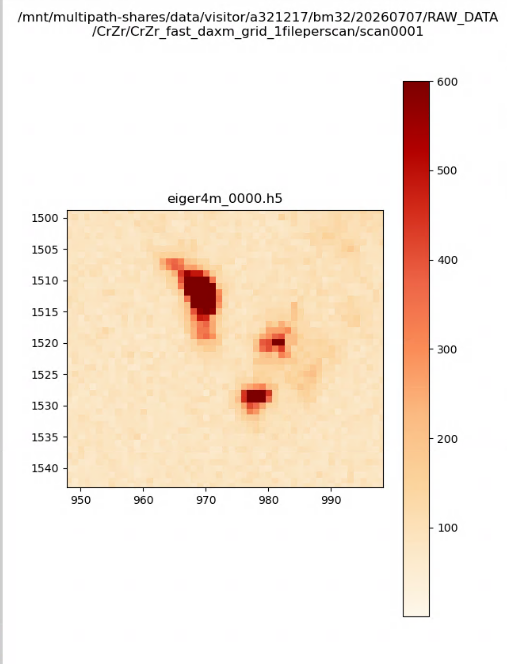

In [ ]:
fig_,ax_ = plt.subplots()
ax_.imshow(boxes[0])

In [ ]:
from multiprocessing import Pool
import os

import h5py
import numpy as np

def extract_box_from_single_dataset(args):
    """
    Helper function to extract a 2D box from a single dataset path.
    Args:
        args: Tuple of (filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx)
    Returns:
        A 3D numpy array of shape (N, box_height, box_width) for the given dataset.
    """
    filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx = args

    # Calculate the slice bounds for the box
    half_height = box_height // 2
    half_width = box_width // 2
    y_start = center_y - half_height
    y_end = center_y + half_height + (1 if box_height % 2 != 0 else 0)
    x_start = center_x - half_width
    x_end = center_x + half_width + (1 if box_width % 2 != 0 else 0)

    with h5py.File(filename, 'r') as f:
        dataset = f[dataset_path]
        if dataset.ndim != 3:
            raise ValueError(f"Dataset {dataset_path} is not 3D (shape: {dataset.shape}).")

        # Check if the box fits within the array dimensions
        if (y_start < 0 or y_end > dataset.shape[1] or
            x_start < 0 or x_end > dataset.shape[2]):
            raise ValueError(
                f"Box of size {box_height}x{box_width} centered at ({center_y}, {center_x}) "
                f"is out of bounds for dataset shape {dataset.shape}."
            )

        # Determine the range of arrays to process
        if end_idx is None:
            end_idx = dataset.shape[0]
        if start_idx < 0 or end_idx > dataset.shape[0] or start_idx >= end_idx:
            raise ValueError(
                f"Invalid subset indices: start_idx={start_idx}, end_idx={end_idx} "
                f"for dataset with {dataset.shape[0]} arrays."
            )

        # Extract the box from each 2D array in the subset
        num_arrays = end_idx - start_idx
        boxes = np.zeros((num_arrays, box_height, box_width), dtype=dataset.dtype)
        for i in range(start_idx, end_idx):
            boxes[i - start_idx] = dataset[i, y_start:y_end, x_start:x_end]

    return boxes


def extract_boxes_parallel(
    filename,
    dataset_paths,
    center_y=1000,
    center_x=1500,
    box_height=11,
    box_width=11,
    start_idx=0,
    end_idx=None,
    num_processes=None
):
    """
    Extracts 2D boxes from multiple dataset paths in parallel using multiprocessing.

    Parameters:
    - filename: Path to the HDF5 file.
    - dataset_paths: List of dataset paths (e.g., ["/entry_0000/CRGIF/eiger4m/data", ...]).
    - center_y: Y-coordinate of the box center (default: 1000).
    - center_x: X-coordinate of the box center (default: 1500).
    - box_height: Height of the box (default: 11).
    - box_width: Width of the box (default: 11).
    - start_idx: Starting index of the subset of arrays (default: 0).
    - end_idx: Ending index of the subset of arrays (default: None).
    - num_processes: Number of CPU processes to use (default: None, uses all available cores).

    Returns:
    - A list of 3D numpy arrays, one for each dataset path.
    """
    if num_processes is None:
        num_processes = os.cpu_count()  # Use all available CPU cores

    # Prepare arguments for each dataset
    args_list = [
        (filename, path, center_y, center_x, box_height, box_width, start_idx, end_idx)
        for path in dataset_paths
    ]

    # Use multiprocessing to parallelize the extraction
    with Pool(processes=num_processes) as pool:
        results = pool.map(extract_box_from_single_dataset, args_list)

    return results

In [ ]:
# Generate 33x33 dataset paths (example)
nmax = 34*34
dataset_paths = [f'{scanindex}.1/measurement/eiger4m' for scanindex in range(1,nmax+1)]

# Extract boxes in parallel
boxes_list = extract_boxes_parallel(
    h5file,
    dataset_paths,
    center_y=1520,
    center_x=982,
    box_height=1,
    box_width=1,
    start_idx=0,
    end_idx=501,  # excluded !  like in range(start_idx, end_idx)
    num_processes=  48 # Use 8 CPU cores
)

# boxes_list is a list of 3D arrays, one for each dataset path
print(f"Extracted {len(boxes_list)} boxes, each of shape {boxes_list[0].shape}")

In [ ]:
len(boxes_list), boxes_list[0].shape

## multiprocessing to read several dataset in a single h5 file with tqdm

WRONG!! not use imap_unordered  !!!

In [ ]:
import h5py
import numpy as np
from multiprocessing import Pool, Manager
from functools import partial
from tqdm.notebook import tqdm

def extract_box_from_single_dataset(args):
    """
    Helper function to extract a 2D box from a single dataset path.
    Args:
        args: Tuple of (filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx)
    Returns:
        A 3D numpy array of shape (N, box_height, box_width) for the given dataset.
    """
    # Unpack the arguments
    filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx = args

    # Calculate the slice bounds for the box
    half_height = box_height // 2
    half_width = box_width // 2
    y_start = center_y - half_height
    y_end = center_y + half_height + (1 if box_height % 2 != 0 else 0)
    x_start = center_x - half_width
    x_end = center_x + half_width + (1 if box_width % 2 != 0 else 0)

    with h5py.File(filename, 'r') as f:
        dataset = f[dataset_path]
        if dataset.ndim != 3:
            raise ValueError(f"Dataset {dataset_path} is not 3D (shape: {dataset.shape}).")

        # Check if the box fits within the array dimensions
        if (y_start < 0 or y_end > dataset.shape[1] or
            x_start < 0 or x_end > dataset.shape[2]):
            raise ValueError(
                f"Box of size {box_height}x{box_width} centered at ({center_y}, {center_x}) "
                f"is out of bounds for dataset shape {dataset.shape}."
            )

        # Determine the range of arrays to process
        if end_idx is None:
            end_idx = dataset.shape[0]
        if start_idx < 0 or end_idx > dataset.shape[0] or start_idx >= end_idx:
            raise ValueError(
                f"Invalid subset indices: start_idx={start_idx}, end_idx={end_idx} "
                f"for dataset with {dataset.shape[0]} arrays."
            )

        # Extract the box from each 2D array in the subset
        num_arrays = end_idx - start_idx
        boxes = np.zeros((num_arrays, box_height, box_width), dtype=dataset.dtype)
        for i in range(start_idx, end_idx):
            boxes[i - start_idx] = dataset[i, y_start:y_end, x_start:x_end]

    return boxes

def extract_boxes_parallel(
    filename,
    dataset_paths,
    center_y=1000,
    center_x=1500,
    box_height=11,
    box_width=11,
    start_idx=0,
    end_idx=None,
    num_processes=None
):
    """
    Extracts 2D boxes from multiple dataset paths in parallel using multiprocessing,
    with a tqdm progress bar for JupyterLab.
    """
    if num_processes is None:
        num_processes = os.cpu_count()

    # Prepare arguments for each dataset as a tuple
    args_list = [
        (filename, path, center_y, center_x, box_height, box_width, start_idx, end_idx)
        for path in dataset_paths
    ]

    # Use tqdm to show progress
    with tqdm(total=len(dataset_paths), desc="Extracting boxes") as pbar:
        with Pool(processes=num_processes) as pool:
            # Use imap_unordered for out-of-order results (faster)
            results = []
            for result in pool.imap_unordered(extract_box_from_single_dataset, args_list):
                results.append(result)
                pbar.update(1)  # Update progress bar

    return results

In [ ]:
1154/2

In [ ]:
# Generate 33x33 dataset paths (example)
nmax = 34*34
num_processes = 64
dataset_paths = [f'{scanindex}.1/measurement/eiger4m' for scanindex in range(1,nmax+1)]

# Extract boxes in parallel
boxes_list = extract_boxes_parallel(
    h5file,
    dataset_paths,
    center_y=Y,
    center_x=X,
    box_height=1,
    box_width=1,
    start_idx= 50 ,#0,
    end_idx=200, #501,  # excluded !  like in range(start_idx, end_idx)
    num_processes=  num_processes # Use n CPU cores
)

# boxes_list is a list of 3D arrays, one for each dataset path
print(f"Extracted {len(boxes_list)} boxes, each of shape {boxes_list[0].shape}")

In [ ]:
allboxes = np.array(boxes_list)

In [ ]:
import sys
allboxes.shape, sys.getsizeof(allboxes)

In [ ]:
# use genfolder to write output  results
folder = Path(h5file).parent
np.save(folder/'pixel-X982-Y1582', allboxes)

In [ ]:
34*34

In [ ]:
allboxes[:34,:,0,0].shape

In [ ]:
fig_,ax_ = plt.subplots()
lineindex = 12
ax_.imshow(allboxes[lineindex*34:lineindex*34+34,:,0,0])

## batch processes (Not tested)

In [ ]:
import h5py
import numpy as np

def extract_box_from_batch(args):
    """
    Helper function to extract 2D boxes from a batch of dataset paths in a single HDF5 file.
    Args:
        args: Tuple of (filename, batch_dataset_paths, center_y, center_x, box_height, box_width, start_idx, end_idx)
              where `batch_dataset_paths` is a list of dataset paths (e.g., ["/path/to/dataset1", ...]).
    Returns:
        A list of 3D numpy arrays, one for each dataset path in the batch.
    """
    filename, batch_dataset_paths, center_y, center_x, box_height, box_width, start_idx, end_idx = args

    # Calculate the slice bounds for the box (same for all datasets in the batch)
    half_height = box_height // 2
    half_width = box_width // 2
    y_start = center_y - half_height
    y_end = center_y + half_height + (1 if box_height % 2 != 0 else 0)
    x_start = center_x - half_width
    x_end = center_x + half_width + (1 if box_width % 2 != 0 else 0)

    boxes_batch = []
    with h5py.File(filename, 'r') as f:
        for dataset_path in batch_dataset_paths:
            dataset = f[dataset_path]
            if dataset.ndim != 3:
                raise ValueError(f"Dataset {dataset_path} is not 3D (shape: {dataset.shape}).")

            # Check if the box fits within the array dimensions
            if (y_start < 0 or y_end > dataset.shape[1] or
                x_start < 0 or x_end > dataset.shape[2]):
                raise ValueError(
                    f"Box of size {box_height}x{box_width} centered at ({center_y}, {center_x}) "
                    f"is out of bounds for dataset shape {dataset.shape}."
                )

            # Determine the range of arrays to process
            if end_idx is None:
                end_idx = dataset.shape[0]
            if start_idx < 0 or end_idx > dataset.shape[0] or start_idx >= end_idx:
                raise ValueError(
                    f"Invalid subset indices: start_idx={start_idx}, end_idx={end_idx} "
                    f"for dataset with {dataset.shape[0]} arrays."
                )

            # Extract the box from each 2D array in the subset
            num_arrays = end_idx - start_idx
            boxes = np.zeros((num_arrays, box_height, box_width), dtype=dataset.dtype)
            for i in range(start_idx, end_idx):
                boxes[i - start_idx] = dataset[i, y_start:y_end, x_start:x_end]
            boxes_batch.append(boxes)

    return boxes_batch

from multiprocessing import Pool
from tqdm.notebook import tqdm
from itertools import islice
import os

def extract_boxes_batched_parallel(
    filename,
    dataset_paths,
    center_y=1000,
    center_x=1500,
    box_height=11,
    box_width=11,
    start_idx=0,
    end_idx=None,
    num_processes=None,
    batch_size=10
):
    """
    Extracts 2D boxes from a single HDF5 file in parallel using batched dataset paths.

    Parameters:
    - filename: Path to the HDF5 file.
    - dataset_paths: List of dataset paths in the file (e.g., ["/path/to/dataset1", ...]).
    - center_y: Y-coordinate of the box center (default: 1000).
    - center_x: X-coordinate of the box center (default: 1500).
    - box_height: Height of the box (default: 11).
    - box_width: Width of the box (default: 11).
    - start_idx: Starting index of the subset of arrays (default: 0).
    - end_idx: Ending index of the subset of arrays (default: None).
    - num_processes: Number of CPU processes to use (default: None, uses all available cores).
    - batch_size: Number of dataset paths to process per batch (default: 10).

    Returns:
    - A list of 3D numpy arrays, one for each dataset path.
    """
    if num_processes is None:
        num_processes = os.cpu_count()

    # Split dataset_paths into batches
    batches = []
    it = iter(dataset_paths)
    while True:
        batch = list(islice(it, batch_size))
        if not batch:
            break
        batches.append(batch)

    # Prepare arguments for each batch
    args_list = [
        (filename, batch, center_y, center_x, box_height, box_width, start_idx, end_idx)
        for batch in batches
    ]

    # Use tqdm to show progress
    with tqdm(total=len(batches), desc="Extracting boxes (batched)") as pbar:
        with Pool(processes=num_processes) as pool:
            results = []
            for batch_results in pool.imap_unordered(extract_box_from_batch, args_list):
                results.extend(batch_results)  # Flatten the list of lists
                pbar.update(1)

    return results

In [ ]:
# Generate 33x33 dataset paths (example)
nmax = 34*34
dataset_paths = [f'{scanindex}.1/measurement/eiger4m' for scanindex in range(1,nmax+1)]

# Extract boxes in parallel
boxes_list_batch = extract_boxes_parallel(
    h5file,
    dataset_paths,
    center_y=1520,
    center_x=982,
    box_height=1,
    box_width=1,
    start_idx=0,
    end_idx=501,  # excluded !  like in range(start_idx, end_idx)
    num_processes=  16, # Use n CPU cores
    batch_size = 10
)

# boxes_list is a list of 3D arrays, one for each dataset path
print(f"Extracted {len(boxes_list_batch)} boxes, each of shape {boxes_list_batch[0].shape}")

In [ ]:
# READ many images and many pixels  first way of data of grid_daxm

In [ ]:
#first way of data of grid_daxm

#1 dataset contains several scans (/scan####). 1 h5 file for 1 scan (501 images)

# too long if 501 are read!!
import h5py
import time

t0 = time.time()

# a single h5 file with 34*34 scans (called dataset for h5 file)
h5file = '/data/visitor/a321217/bm32/20260707/RAW_DATA/CrZr/CrZr_fast_daxm_grid_1fileperscan/CrZr_fast_daxm_grid_1fileperscan.h5'

scanindex=1
imageindex= 0

with h5py.File(h5file, 'r', locking=False) as f:
    scanindex=1
    
    # whole scan data (LONG)
    #scandata = f[f'{scanindex}.1/measurement/eiger4m'][()]
    
    #scandata = f[f'{scanindex}.1/measurement/eiger4m'][:50, 1000:1100, 1000:1100]
    scandata = f[f'{scanindex}.1/measurement/eiger4m'][:, 1000:1002, 1000:1002]
    #scandata = f[f'{scanindex}.1/measurement/eiger4m'][:50]
    
    #imgdata = f[f'{scanindex}.1/measurement/eiger4m'][imageindex]

tf = time.time()
et = tf-t0
print(f'elpased time {et:.2f} sec')


## one way but too long  with few cpus ??

import h5py
import multiprocessing
import time
from tqdm import tqdm

def load_scan(args, mean=True):
    h5file, scan_index, slice_params = args

    with h5py.File(h5file, 'r', locking=False) as f:
        # Load the specified slice for the scan
        data = f[f'{scan_index}.1/measurement/eiger4m'][slice_params]
        if mean:
            rdata = np.mean(data) - .25*(np.amin(data[:,0])+ np.amin(data[:,-1])+np.amin(data[0,:])+np.amin(data[-1,:]))
        else:
            rdata=data
    return rdata

if __name__ == "__main__":
    h5file = '/data/visitor/a321217/bm32/20260707/RAW_DATA/CrZr/CrZr_fast_daxm_grid_1fileperscan/CrZr_fast_daxm_grid_1fileperscan.h5'

    # Example: Load all 34x34 scans, each with a slice [:, 1000:1002, 1000:1002]
    scan_indices = [i for i in range(1, 34*34 + 1)]  
    #scan_indices = [i for i in range(1, 2*5 + 1)]  # Adjust range as needed
    slice_params = (slice(None), slice(X-7, X+8), slice(Y-7, Y+8))

    # Prepare tasks: (h5file, scan_index, slice_params)
    tasks = [(h5file, scan_idx, slice_params) for scan_idx in scan_indices]

    t0 = time.time()
    # Use imap_unordered for progress bar (faster, unordered results)
    # Use imap for ordered results (slower, but preserves order)
    with multiprocessing.Pool() as pool:
        results = list(tqdm(pool.imap(load_scan, tasks), total=len(tasks), desc="Loading scans"))
    tf = time.time()
    et = tf - t0
    print(f'Elapsed time: {et:.2f} sec')

np.array(results).shape

# 34*34 scans
#!ls {Path(h5file).parent}

## use of magnifix slurm

ncpuspertask=192
partition= 'magnifix'

logfolder = '/home/esrf/micha/'

script_path = '/data/bm32/inhouse/SOFT/lauetoolsDEV/lauetools/LaueTools/notebooks/load_daxmscans.py'
script_folder = '/data/bm32/inhouse/SOFT/lauetoolsDEV/lauetools/LaueTools/notebooks'


shell_file = Path(script_folder)/'loaddaxm.sh'

shell_script =f"""#!/bin/bash -l
#SBATCH -n 1                # Number of tasks
#SBATCH -c {ncpuspertask}               # CPUs per task
#SBATCH -p {partition}
#SBATCH --time=00:06:00    # Time limit
#SBATCH --mem-per-cpu=80M

module load mamba
conda activate /data/bm32/inhouse/SOFT/lauetoolsDEV

which python
echo 'launching python script to load daxm scans'
python {script_path}"""

with open(shell_file, 'w') as f:
    f.write(shell_script)

print(f"SLURM script generated at: {shell_file}")

!cd {script_folder}

!chmod 744 loaddaxm.sh

!sbatch loaddaxm.sh

!squeue -u micha

#on rnice, module load  ~~~ slurm-utils
#reportseff -u micha --since m=30

## read result h5 file

import h5py
import numpy as np

# Path to the generated HDF5 file
output_path = '/data/visitor/a321217/bm32/20260707/PROCESSED_DATA/loaddaxmscans_results.h5'

# Open the file in read mode
with h5py.File(output_path, 'r') as f:
    # --- Read the dataset ---
    daxmscan = f['daxmscan'][:]  # Load the entire dataset as a NumPy array
    print(f"Shape of daxmscan: {daxmscan.shape}")  # Should be (n_scans, height, width)

    # --- Read attributes ---
    scan_indices = f.attrs['scan_indices']  # Array of scan indices
    slice_params = f.attrs['slice_params']  # String representation of slice_params
    elapsed_time_sec = f.attrs['elapsed_time_sec']  # Elapsed time in seconds

    print(f"Scan indices: {scan_indices}")
    print(f"Slice parameters: {slice_params}")
    print(f"Elapsed time: {elapsed_time_sec:.2f} sec")

    # --- Example: Access a specific scan ---
    #scan_idx = 0  # Example: First scan
    #print(f"Data for scan {scan_indices[scan_idx]}:\n{daxmscan[scan_idx]}")

daxmscan.shape

dd = daxmscan[:,:,0, 0]
dd.shape

fig0_,ax0_ = plt.subplots()
lineindex = 18
ax0_.imshow(dd[lineindex*34:lineindex*34+34,:], vmin=0, vmax=2000)
ax0_.set_xlabel('relative image index')
ax0_.set_ylabel('fast axis motor index\nXECH')
ax0_.set_title(f'for (horizontal) line index {lineindex}')



# new way of grid daxm data

1 dataset/scan0001 per daxm scan

In [ ]:
# 34*34 h5 files, ecah file has got 501 stacked images
h5file = '/data/visitor/a321217/bm32/20260707/RAW_DATA/CRZR/CRZR_grid_index_0_row_col_0_0/CRZR_grid_index_0_row_col_0_0.h5'

with h5py.File(h5file, 'r', locking=False) as f:
    scanindex=1
    #scandata = f[f'{scanindex}.1/measurement/eiger4m'][()]   # whole scan
    scandata = f[f'{scanindex}.1/measurement/eiger4m'][:50]  # some parts of it


In [ ]:
h5file = '/data/visitor/a321217/bm32/20260707/RAW_DATA/CRZR/CRZR_grid_index_0_row_col_0_0/CRZR_grid_index_0_row_col_0_0.h5'


In [ ]:
motor1= 'xech'
motor2= 'yech'

rawdata = '/data/visitor/a321217/bm32/20260707/RAW_DATA'

grid_daxm_dimensions = 34,34 # X fast (motor1) , Y slow (motor2)
nbscans = grid_daxm_dimensions[0]*grid_daxm_dimensions[1]
ix = 0
m1list = []
m2list = []
filenames = []
for row in range(grid_daxm_dimensions[0]): # yech
    for col in range(grid_daxm_dimensions[1]):  # xech
        
        h5file = Path(rawdata)/f'CRZR/CRZR_grid_index_{ix}_row_col_{row}_{col}/CRZR_grid_index_{ix}_row_col_{row}_{col}.h5'
        filenames.append(h5file)
        with h5py.File(h5file, 'r', locking=False) as f:
            
            scanindex = 1
            m1 = float(f[f'{scanindex}.1/instrument/positioners/{motor1}'][()])
            m2 =float(f[f'{scanindex}.1/instrument/positioners/{motor2}'][()])
            m1list.append(m1)
            m2list.append(m2)

        if ix%(nbscans//10)==0: print('row, col', row, col)
        ix=ix+1

stepsize_motor1 = m1list[1]-m1list[0]
stepsize_motor2 = m2list[1]-m2list[0]
if np.fabs(stepsize_motor1)<0.00001:
    print(f'{motor2} is the fast motor for the grid daxm')
    stepsize_motor1 =m1list[grid_daxm_dimensions[0]]-m1list[0]  # to be checked!
else:
    print(f'{motor1} is the fast motor for the grid daxm')
    stepsize_motor2 =m2list[grid_daxm_dimensions[0]]-m2list[0]
print(f'stepsize_motor1 {np.round(stepsize_motor1,5)} mm')
print(f'stepsize_motor2 {np.round(stepsize_motor2,5)} mm')

## read first of daxm scan located a row (Y), col (X)

In [ ]:
def extract_box_from_single_dataset(args):
    """
    Helper function to extract a 2D box from a single dataset path.
    Uses vectorized NumPy slicing for maximum performance.

    Args:
        args: Tuple of (filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx)
    Returns:
        A 3D numpy array of shape (N, box_height, box_width) for the given dataset.
    """
    filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx = args

    # Calculate the slice bounds for the box
    half_height = box_height // 2
    half_width = box_width // 2
    y_start = center_y - half_height
    y_end = center_y + half_height + (1 if box_height % 2 != 0 else 0)
    x_start = center_x - half_width
    x_end = center_x + half_width + (1 if box_width % 2 != 0 else 0)

    with h5py.File(filename, 'r') as f:
        dataset = f[dataset_path]
        if dataset.ndim != 3:
            raise ValueError(f"Dataset {dataset_path} is not 3D (shape: {dataset.shape}).")

        # Check if the box fits within the array dimensions
        if (y_start < 0 or y_end > dataset.shape[1] or
            x_start < 0 or x_end > dataset.shape[2]):
            raise ValueError(
                f"Box of size {box_height}x{box_width} centered at ({center_y}, {center_x}) "
                f"is out of bounds for dataset shape {dataset.shape}."
            )

        # Determine the range of arrays to process
        if end_idx is None:
            end_idx = dataset.shape[0]
        if start_idx < 0 or end_idx > dataset.shape[0] or start_idx >= end_idx:
            raise ValueError(
                f"Invalid subset indices: start_idx={start_idx}, end_idx={end_idx} "
                f"for dataset with {dataset.shape[0]} arrays."
            )

        # Vectorized extraction: slice all arrays at once
        boxes = dataset[start_idx:end_idx, y_start:y_end, x_start:x_end]

    return boxes

In [ ]:
row, col =17, 17
ix = row*grid_daxm_dimensions[0]+col

h5file = Path(rawdata)/f'CRZR/CRZR_grid_index_{ix}_row_col_{row}_{col}/CRZR_grid_index_{ix}_row_col_{row}_{col}.h5'

with h5py.File(h5file, 'r', locking=False) as f:
    scanindex=1
    lp = f[f'{scanindex}.1/measurement/eiger4m'][0]

In [ ]:
row, col =17, 17
ix = row*grid_daxm_dimensions[0]+col

h5file = Path(rawdata)/f'CRZR/CRZR_grid_index_{ix}_row_col_{row}_{col}/scan0001/eiger4m_0000.h5'

with h5py.File(h5file, 'r', locking=False) as f:
    scanindex=1
    lps = f[f'entry_0000/measurement/data'][()]
    lp = f[f'entry_0000/measurement/data'][0]


In [ ]:

fig, ax = plt.subplots()
ax.imshow(lp, vmin=0, vmax=200)
ax.set_xlim(700,770)
ax.set_ylim(875, 770)

In [ ]:
np.linspace(-3,3,7)

In [ ]:
# select mosaic around X, Y over the grid daxm 
row0, col0 =17, 17
hrow, hcol = 11,11


grid_daxm_dimensions = 34,34  # fast X, slow Y

hboxsizex, hboxsizey=7,9
X,Y = 744, 796
X,Y = 700, 796
X,Y = 708, 774
# X,Y = 732, 815

allcrops=np.zeros((2*hrow+1,2*hcol+1,hboxsizey*2+1,hboxsizex*2+1))
maxvalues = np.zeros((2*hrow+1,2*hcol+1))
for idy, dy in enumerate(np.linspace(-hrow,hrow,2*hrow+1)):
    for idx, dx in enumerate(np.linspace(-hcol,hcol,2*hcol+1)):
        row = row0+int(dy)
        col = col0+int(dx)
        # print(row, col)
        # print(idy,idx)
        
        ix = row*grid_daxm_dimensions[0]+col
        
        h5file = Path(rawdata)/f'CRZR/CRZR_grid_index_{ix}_row_col_{row}_{col}/scan0001/eiger4m_0000.h5'
        
        with h5py.File(h5file, 'r', locking=False) as f:
            #lps = f[f'entry_0000/measurement/data'][()]
            lp_crop = f[f'entry_0000/measurement/data'][0][Y-hboxsizey:Y+hboxsizey+1,X-hboxsizex:X+hboxsizex+1]
            #allcrops[idy,idx]=lp_crop

            maxvalues[idy,idx]=np.amax(lp_crop)
        
    

In [ ]:
fig, ax =plt.subplots()
ax.imshow(maxvalues, vmin=0, vmax=200)

plt.show()

In [ ]:
fig, ax =plt.subplots(2*hrow+1,2*hcol+1)
for i in range(2*hrow+1):
    for j in range(2*hcol+1):
        ax[i,j].imshow(allcrops[i,j], vmin=0, vmax=200)

plt.show()

In [ ]:
X,Y = 1165, 880
X,Y = 744, 796
X,Y = 708,774

fig2, ax2 = plt.subplots()
sig = lps[:,Y, X]
bckg = lps[:,Y, X+4]
diff = np.array(sig, np.int32)-np.array(bckg, np.int32)
ax2.plot(sig, label='scattering')
ax2.plot(bckg, 'grey', label='fluo')

ax2.plot(diff, 'red', label='scattering-fluo')
ax2.grid()
ax2.set_title(f'intensity profile of pixel [{X},{Y}]')
ax2.legend()

In [ ]:
import numpy as np
from scipy.signal import savgol_filter


# Smooth and compute derivative
window_length = 11  # Must be odd, typically 5-21
polyorder = 3       # Polynomial order (must be < window_length)
dy = savgol_filter(diff, window_length, polyorder, deriv=1, delta=1)
dyraw = savgol_filter(diff, window_length, polyorder, deriv=1, delta=1)

In [ ]:
fig3, ax3 = plt.subplots()

ax3.plot(diff)
ax3.plot(-dy, 'orange')


ax3.grid()
ax3.set_title(f'intensity profile and inverse of derivative of pixel [{X},{Y}]')

In [ ]:
#X,Y = 1165, 880

filename =h5file
dataset_path = f'1.1/measurement/eiger4m'
center_x, center_y = X,Y
box_width, box_height = 1,1
start_idx, end_idx = 46,130


args = filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx


boxes = extract_box_from_single_dataset(args)

In [ ]:
import h5py
import numpy as np
from multiprocessing import Pool
from tqdm.notebook import tqdm
import os
import warnings

def extract_box_from_file(args):
    """
    Helper function to extract a 2D box from a single HDF5 file.
    Args:
        args: Tuple of (filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx)
    Returns:
        A 3D numpy array of shape (N, box_height, box_width) for the given file.
    """
    filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx = args

    # Calculate slice bounds for the box
    half_height = box_height // 2
    half_width = box_width // 2
    y_start = center_y - half_height
    y_end = center_y + half_height + (1 if box_height % 2 != 0 else 0)
    x_start = center_x - half_width
    x_end = center_x + half_width + (1 if box_width % 2 != 0 else 0)

    try:
        with h5py.File(filename, 'r', locking=False) as f:
            dataset = f[dataset_path]
            if dataset.ndim != 3:
                warnings.warn(f"Dataset {dataset_path} in {filename} is not 3D (shape: {dataset.shape}). Skipping.")
                return None

            # Check if the box fits within the array dimensions
            if (y_start < 0 or y_end > dataset.shape[1] or
                x_start < 0 or x_end > dataset.shape[2]):
                warnings.warn(
                    f"Box of size {box_height}x{box_width} centered at ({center_y}, {center_x}) "
                    f"is out of bounds for dataset shape {dataset.shape} in {filename}. Skipping."
                )
                return None

            # Determine the range of arrays to process
            if end_idx is None:
                end_idx = dataset.shape[0]
            if start_idx < 0 or end_idx > dataset.shape[0] or start_idx >= end_idx:
                warnings.warn(
                    f"Invalid subset indices: start_idx={start_idx}, end_idx={end_idx} "
                    f"for dataset with {dataset.shape[0]} arrays in {filename}. Skipping."
                )
                return None

            # Extract the box from each 2D array in the subset
            num_arrays = end_idx - start_idx
            boxes = np.zeros((num_arrays, box_height, box_width), dtype=dataset.dtype)
            for i in range(start_idx, end_idx):
                boxes[i - start_idx] = dataset[i, y_start:y_end, x_start:x_end]

        return boxes

    except Exception as e:
        warnings.warn(f"Failed to process {filename}: {str(e)}. Skipping.")
        return None

def extract_boxes_from_files_parallel(
    filenames,
    dataset_path="1.1/measurement/eiger4m",
    center_y=1000,
    center_x=1500,
    box_height=11,
    box_width=11,
    start_idx=0,
    end_idx=None,
    num_processes=None
):
    """
    Extracts 2D boxes from multiple HDF5 files in parallel.

    Parameters:
    - filenames: List of paths to HDF5 files (e.g., ["scan1.h5", "scan2.h5", ...]).
    - dataset_path: Path to the dataset inside each file (default: "1.1/measurement/eiger4m").
    - center_y: Y-coordinate of the box center (default: 1000).
    - center_x: X-coordinate of the box center (default: 1500).
    - box_height: Height of the box (default: 11).
    - box_width: Width of the box (default: 11).
    - start_idx: Starting index of the subset of arrays (default: 0).
    - end_idx: Ending index of the subset of arrays (default: None, meaning all arrays).
    - num_processes: Number of CPU processes to use (default: None, uses all available cores).

    Returns:
    - A list of 3D numpy arrays, one for each file (skips failed files).
    """
    if num_processes is None:
        num_processes = os.cpu_count()

    # Prepare arguments for each file
    args_list = [
        (filename, dataset_path, center_y, center_x, box_height, box_width, start_idx, end_idx)
        for filename in filenames
    ]

    # Use tqdm to show progress
    with tqdm(total=len(filenames), desc="Extracting boxes") as pbar:
        with Pool(processes=num_processes) as pool:
            results = []
            for result in pool.imap(extract_box_from_single_dataset, args_list):  # Use imap instead
                if result is not None:
                    results.append(result)
                pbar.update(1)

    return results

In [ ]:
#import glob

# Example: Generate filenames for a 34x34 grid (adjust pattern as needed)
# filenames = sorted(glob.glob("scan_*.h5"))  # Or manually define the list
# if len(filenames) != 34 * 34:
#     warnings.warn(f"Expected 1156 files, but found {len(filenames)}. Check your file pattern.")


# Extract boxes in parallel
boxes_list = extract_boxes_from_files_parallel(
    filenames,
    dataset_path="1.1/measurement/eiger4m",  # Path inside each file
    center_y=Y,                          # Y-coordinate of box center
    center_x=X,                           # X-coordinate of box center
    box_height=1,                           # Height of the box (e.g., 1 for a single pixel)
    box_width=1,                            # Width of the box
    start_idx=46,                           # Start at the first array
    end_idx=130,                           # Exclusive end (process all 501 arrays)
    num_processes=48                      # Use 32 CPUs (adjust based on your system)
)

print(f"Extracted {len(boxes_list)} boxes, each of shape {boxes_list[0].shape}")

In [ ]:
! ls -alp {h5file}

In [ ]:
# to test if data is chunked
import h5py

# Open your HDF5 file
with h5py.File(h5file, 'r', locking=False) as f:
    dataset = f["1.1/measurement/eiger4m"]  # Replace with your dataset path

    # Check if the dataset is chunked
    if dataset.chunks is not None:
        print(f"Dataset is chunked with chunk shape: {dataset.chunks}")
    else:
        print("Dataset is NOT chunked (contiguous storage).")

    # Additional useful properties
    print(f"Dataset shape: {dataset.shape}")
    print(f"Dataset dtype: {dataset.dtype}")
    print(f"Compression: {dataset.compression}")

In [ ]:
imagefile='/data/visitor/a321217/bm32/20260707/RAW_DATA/LaB6_2/LaB6_2_gedaxm/scan0001/eiger4m_0000.h5'

! ls -alp {imagefile}

In [ ]:
501*5.9

In [ ]:
imagefile2 = '/data/visitor/a321217/bm32/20260707/RAW_DATA/CRZR/CRZR_grid_index_595_row_col_17_17/scan0001/eiger4m_0000.h5'

In [ ]:
# to test if data is chunked
import h5py

# Open your HDF5 file
with h5py.File(imagefile2, 'r', locking=False) as f:
    dataset = f["entry_0000/measurement/data"]  # Replace with your dataset path

    # Check if the dataset is chunked
    if dataset.chunks is not None:
        print(f"Dataset is chunked with chunk shape: {dataset.chunks}")
    else:
        print("Dataset is NOT chunked (contiguous storage).")

    # Additional useful properties
    print(f"Dataset shape: {dataset.shape}")
    print(f"Dataset dtype: {dataset.dtype}")
    print(f"Compression: {dataset.compression}")

# treat the data

In [ ]:
len(boxes_list)

In [ ]:
allboxes = np.array(boxes_list)

In [ ]:
import sys
allboxes.shape, sys.getsizeof(allboxes)

In [ ]:
allboxes[:34,:,0,0].shape

In [ ]:
fig0_,ax0_ = plt.subplots()
lineindex = 17
ax0_.imshow(allboxes[lineindex*34:lineindex*34+34,:,0,0], vmin=0, vmax=200)
ax0_.set_xlabel('relative image index')
ax0_.set_ylabel('fast axis motor index\nXECH')
ax0_.set_title(f'for (horizontal) line index {lineindex}')

In [ ]:
fig0_,ax0_ = plt.subplots()
columnindex = 17
ax0_.imshow(allboxes[columnindex::34,:,0,0], vmin=0, vmax=200)
ax0_.set_xlabel('relative image index')
ax0_.set_ylabel('slow axis motor index\nYECH')
ax0_.set_title(f'for (vertical) column index {columnindex}')

In [ ]:
row, col = 17,17
np.arange(1156)[col::34], np.arange(1156)[row*34:(row+1)*34]

In [ ]:
1156//34

In [ ]:
17*34+17